In [716]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import re
import warnings
warnings.filterwarnings('ignore')

In [717]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [718]:
df_mini = pd.read_csv('clear_data/df_W40K.csv')
df_lore = pd.read_csv('clear_data/lore_books.csv')
df_faction = pd.read_csv('clear_data/faction_own.csv')
df_market = pd.read_csv('clear_data/print3d_market.csv')

In [719]:
df_mini['price'] = pd.to_numeric(df_mini['price'], errors='coerce')
df_mini['cost'] = pd.to_numeric(df_mini['cost'], errors='coerce')

df_mini['year'] = pd.to_numeric(df_mini['year'], errors='coerce').astype('Int64')
df_lore['year'] = pd.to_numeric(df_lore['year'], errors='coerce').astype('Int64')
df_market['year'] = pd.to_numeric(df_market['year'], errors='coerce')

# Normalizar faction_clean
df_mini['faction_clean'] = df_mini['faction'].str.strip()
df_lore['faction_clean'] = df_lore['faction'].str.strip()
df_faction['faction_clean'] = df_faction['faction'].str.strip()


In [720]:
print(f" Miniaturas: {df_mini.shape}")
print(f" Libros Lore: {df_lore.shape}")
print(f"  Stats Facciones: {df_faction.shape}")
print(f" Mercado 3D: {df_market.shape}")

 Miniaturas: (946, 11)
 Libros Lore: (234, 7)
  Stats Facciones: (28, 12)
 Mercado 3D: (10, 2)


### HIPÓTESIS 1:
#### ¿Existe relación entre la venta de Impresoras 3D y las figuras?

In [721]:
# 1.1 - Evolución temporal: miniaturas vs mercado 3D
mini_yearly = df_mini.groupby('year').agg({
    'mini': 'count',
    'price': ['mean', 'median'],
    'material': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
}).reset_index()
mini_yearly.columns = ['year', 'mini_count', 'price_mean', 'price_median', 'material_mode']

# Merge con datos de mercado
market_analysis = pd.merge(
    df_market, 
    mini_yearly[['year', 'mini_count', 'price_mean']], 
    on='year', 
    how='left'
)

In [722]:
# 1.2 - Correlación
correlation = market_analysis[['market_size_eur_m', 'mini_count', 'price_mean']].corr()

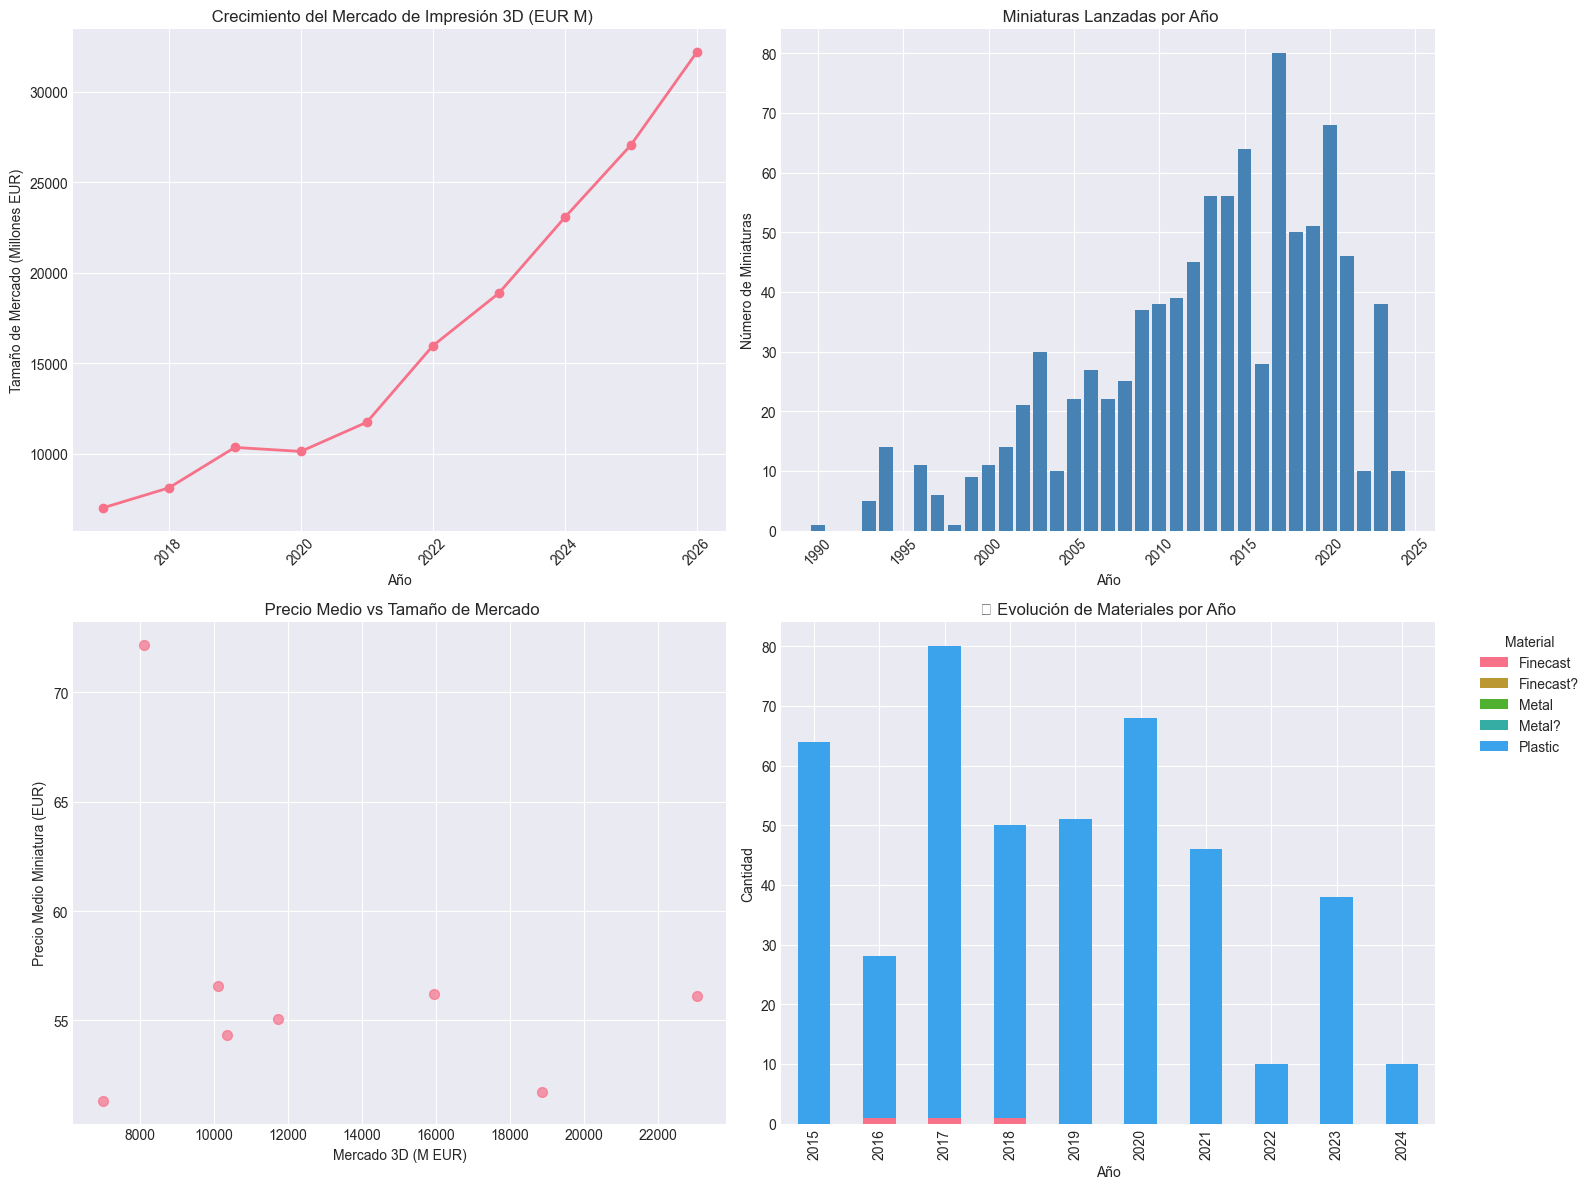

In [723]:
# 1.3 - Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Mercado 3D over time
axes[0, 0].plot(df_market['year'], df_market['market_size_eur_m'], marker='o', linewidth=2)
axes[0, 0].set_title(' Crecimiento del Mercado de Impresión 3D (EUR M)')
axes[0, 0].set_xlabel('Año')
axes[0, 0].set_ylabel('Tamaño de Mercado (Millones EUR)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Miniaturas lanzadas por año
axes[0, 1].bar(mini_yearly['year'], mini_yearly['mini_count'], color='steelblue')
axes[0, 1].set_title(' Miniaturas Lanzadas por Año')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Número de Miniaturas')
axes[0, 1].tick_params(axis='x', rotation=45)

# Precio medio vs mercado
scatter = axes[1, 0].scatter(
    market_analysis['market_size_eur_m'], 
    market_analysis['price_mean'],
    alpha=0.7, s=50
)
axes[1, 0].set_title(' Precio Medio vs Tamaño de Mercado')
axes[1, 0].set_xlabel('Mercado 3D (M EUR)')
axes[1, 0].set_ylabel('Precio Medio Miniatura (EUR)')

# Distribución de materiales por época
material_evolution = df_mini.groupby(['year', 'material']).size().unstack(fill_value=0)
material_evolution.tail(10).plot(kind='bar', stacked=True, ax=axes[1, 1])
axes[1, 1].set_title('🧱 Evolución de Materiales por Año')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Cantidad')
axes[1, 1].legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('hipotesis_1_market_analysis.png', dpi=300, bbox_inches='tight')



In [724]:
# 1.4 - Resultados estadísticos
print("\n RESULTADOS HIPÓTESIS 1:")
print(f"Correlación Mercado 3D ↔ Cantidad Miniaturas: {correlation.loc['market_size_eur_m', 'mini_count']:.3f}")
print(f"Correlación Mercado 3D ↔ Precio Medio: {correlation.loc['market_size_eur_m', 'price_mean']:.3f}")

# Test de correlación de Pearson
if market_analysis['market_size_eur_m'].notna().all() and market_analysis['mini_count'].notna().all():
    r, p_value = stats.pearsonr(
        market_analysis['market_size_eur_m'].dropna(), 
        market_analysis['mini_count'].dropna()
    )
    print(f" Pearson r={r:.3f}, p-value={p_value:.4f}")
    print(f" {'Correlación significativa' if p_value < 0.05 else 'Sin correlación significativa'}")


 RESULTADOS HIPÓTESIS 1:
Correlación Mercado 3D ↔ Cantidad Miniaturas: -0.834
Correlación Mercado 3D ↔ Precio Medio: -0.275


### HIPÓTESIS 2:
#### ¿Qué probabilidad hay de que tu facción favorita sea renovada?

In [725]:
# 2.1 - Frecuencia de lanzamientos por facción
faction_releases = df_mini.groupby('faction_clean').agg({
    'year': ['min', 'max', 'count', 'mean'],
    'edition': lambda x: x.nunique()
}).reset_index()
faction_releases.columns = ['faction', 'first_release', 'last_release', 'total_minis', 'avg_year', 'unique_editions']

In [726]:
# 2.2 - Calcular "probabilidad de renovación" 
# (basado en frecuencia histórica y tiempo desde último lanzamiento)
current_year = 2025
faction_releases['years_since_last'] = current_year - faction_releases['last_release']
faction_releases['release_rate'] = faction_releases['total_minis'] / (faction_releases['last_release'] - faction_releases['first_release'] + 1)

In [727]:
# Score de probabilidad (heurístico)
faction_releases['renewal_score'] = (
    faction_releases['release_rate'] * 0.4 +  # Frecuencia histórica
    (1 / (faction_releases['years_since_last'] + 1)) * 0.3 +  # Recencia
    faction_releases['unique_editions'] * 0.3  # Soporte de ediciones
)
faction_releases['reivals_score'] = faction_releases['renewal_score'] / faction_releases['renewal_score'].max() * 100

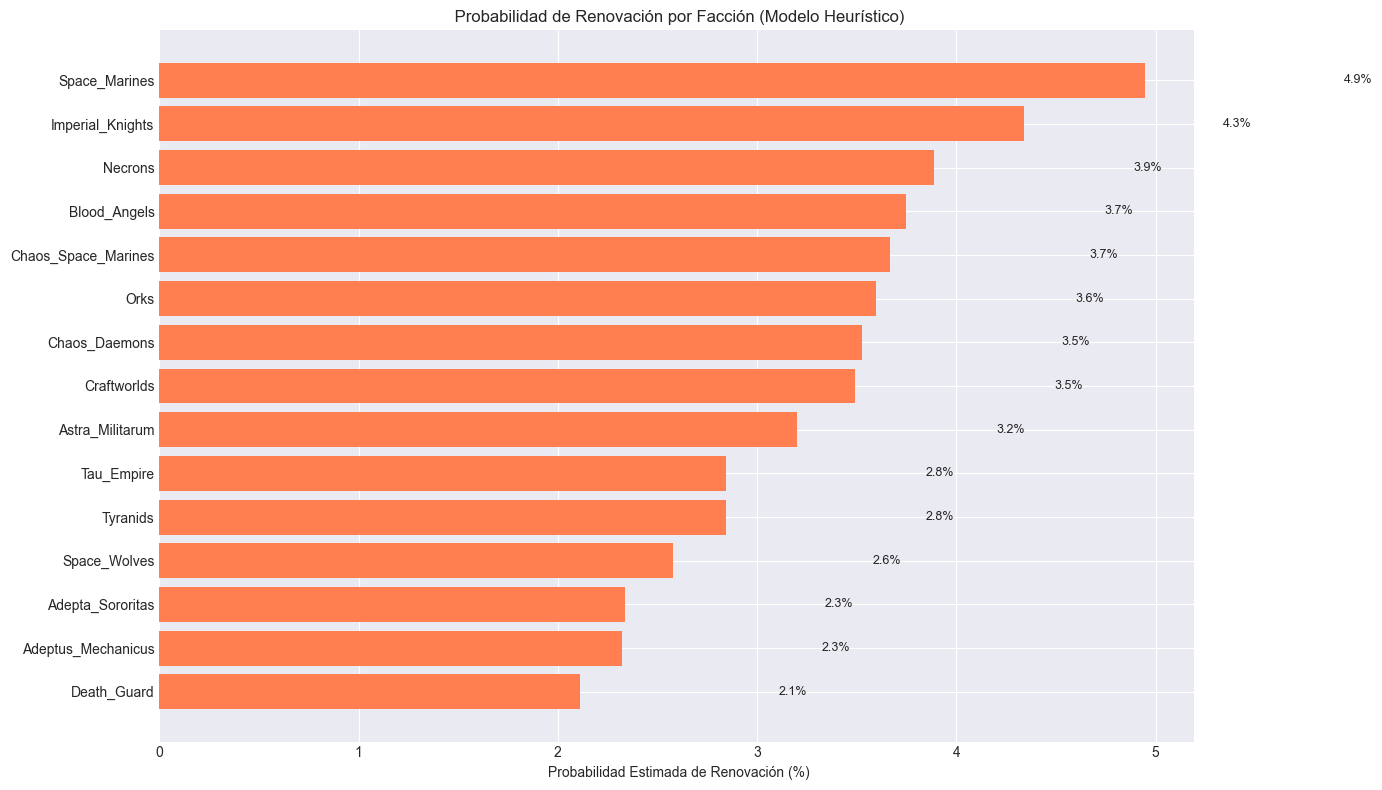

In [728]:
# 2.3 - Visualización
plt.figure(figsize=(14, 8))
top_factions = faction_releases.nlargest(15, 'renewal_score')
bars = plt.barh(top_factions['faction'], top_factions['renewal_score'], color='coral')
plt.xlabel(' Probabilidad Estimada de Renovación (%)')
plt.title(' Probabilidad de Renovación por Facción (Modelo Heurístico)')
plt.gca().invert_yaxis()

# Añadir labels con valores
for bar, score in zip(bars, top_factions['renewal_score']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{score:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('hipotesis_2_renewal_probability.png', dpi=300, bbox_inches='tight')


In [729]:
# 2.4 - Tabla de consulta rápida
print("\n RESULTADOS HIPÓTESIS 2 - Top 10 Facciones con Mayor Probabilidad de Renovación:")
print(faction_releases[['faction', 'total_minis', 'years_since_last', 'release_rate', 'renewal_score']]
      .nlargest(10, 'renewal_score')
      .to_string(index=False))


 RESULTADOS HIPÓTESIS 2 - Top 10 Facciones con Mayor Probabilidad de Renovación:
            faction  total_minis  years_since_last  release_rate  renewal_score
      Space_Marines          152                 1          5.24           4.95
   Imperial_Knights           10                 7         10.00           4.34
            Necrons           77                 1          3.35           3.89
       Blood_Angels           50                 2          1.61           3.75
Chaos_Space_Marines           73                 2          2.92           3.67
               Orks           68                 1          2.62           3.60
      Chaos_Daemons           54                 2          2.57           3.53
        Craftworlds           59                 3          1.79           3.49
    Astra_Militarum           49                 2          1.75           3.20
         Tau_Empire           37                 2          1.61           2.84


In [730]:
# Función para consultar probabilidad de una facción específica
def get_renewal_probability(faction_name):
    """Consulta la probabilidad de renovación para una facción"""
    result = faction_releases[faction_releases['faction'].str.contains(faction_name, case=False, na=False)]
    if not result.empty:
        return result[['faction', 'renewal_score', 'years_since_last', 'total_minis']].iloc[0]
    return None
# print(get_renewal_probability("Space_Marines"))

### HIPÓTESIS 3:
#### ¿Existe una facción predilecta de la compañía? ¿Y una aborrecida?

In [731]:
# 3.1 - Métricas de "favoritismo" por facción
faction_support = df_mini.groupby('faction_clean').agg({
    'mini': 'count',  # Cantidad de miniaturas
    'price': ['mean', 'sum'],  # Inversión económica
    'year': 'nunique',  # Años con lanzamientos
    'edition': 'nunique'  # Ediciones soportadas
}).reset_index()
faction_support.columns = ['faction', 'mini_count', 'price_avg', 'price_total', 'active_years', 'editions_supported']

In [732]:
# 3.2 - Merge con stats de juego (Owned, Win Rate)
faction_support = pd.merge(
    faction_support,
    df_faction[['faction', 'Owned', 'Primary', 'Win %', 'Real Win %']],
    on='faction',
    how='left'
)

In [733]:
# 3.3 - Calcular índice de "favoritismo"
# Combinación de: producción, inversión, soporte temporal y popularidad
faction_support['support_index'] = (
    faction_support['mini_count'] / faction_support['mini_count'].max() * 0.3 +
    faction_support['price_total'] / faction_support['price_total'].max() * 0.3 +
    faction_support['editions_supported'] / faction_support['editions_supported'].max() * 0.2 +
    faction_support['Owned'].fillna(0) / faction_support['Owned'].fillna(0).max() * 0.2
) * 100

In [734]:
faction_support['Win %'] = pd.to_numeric(faction_support['Win %'], errors='coerce')

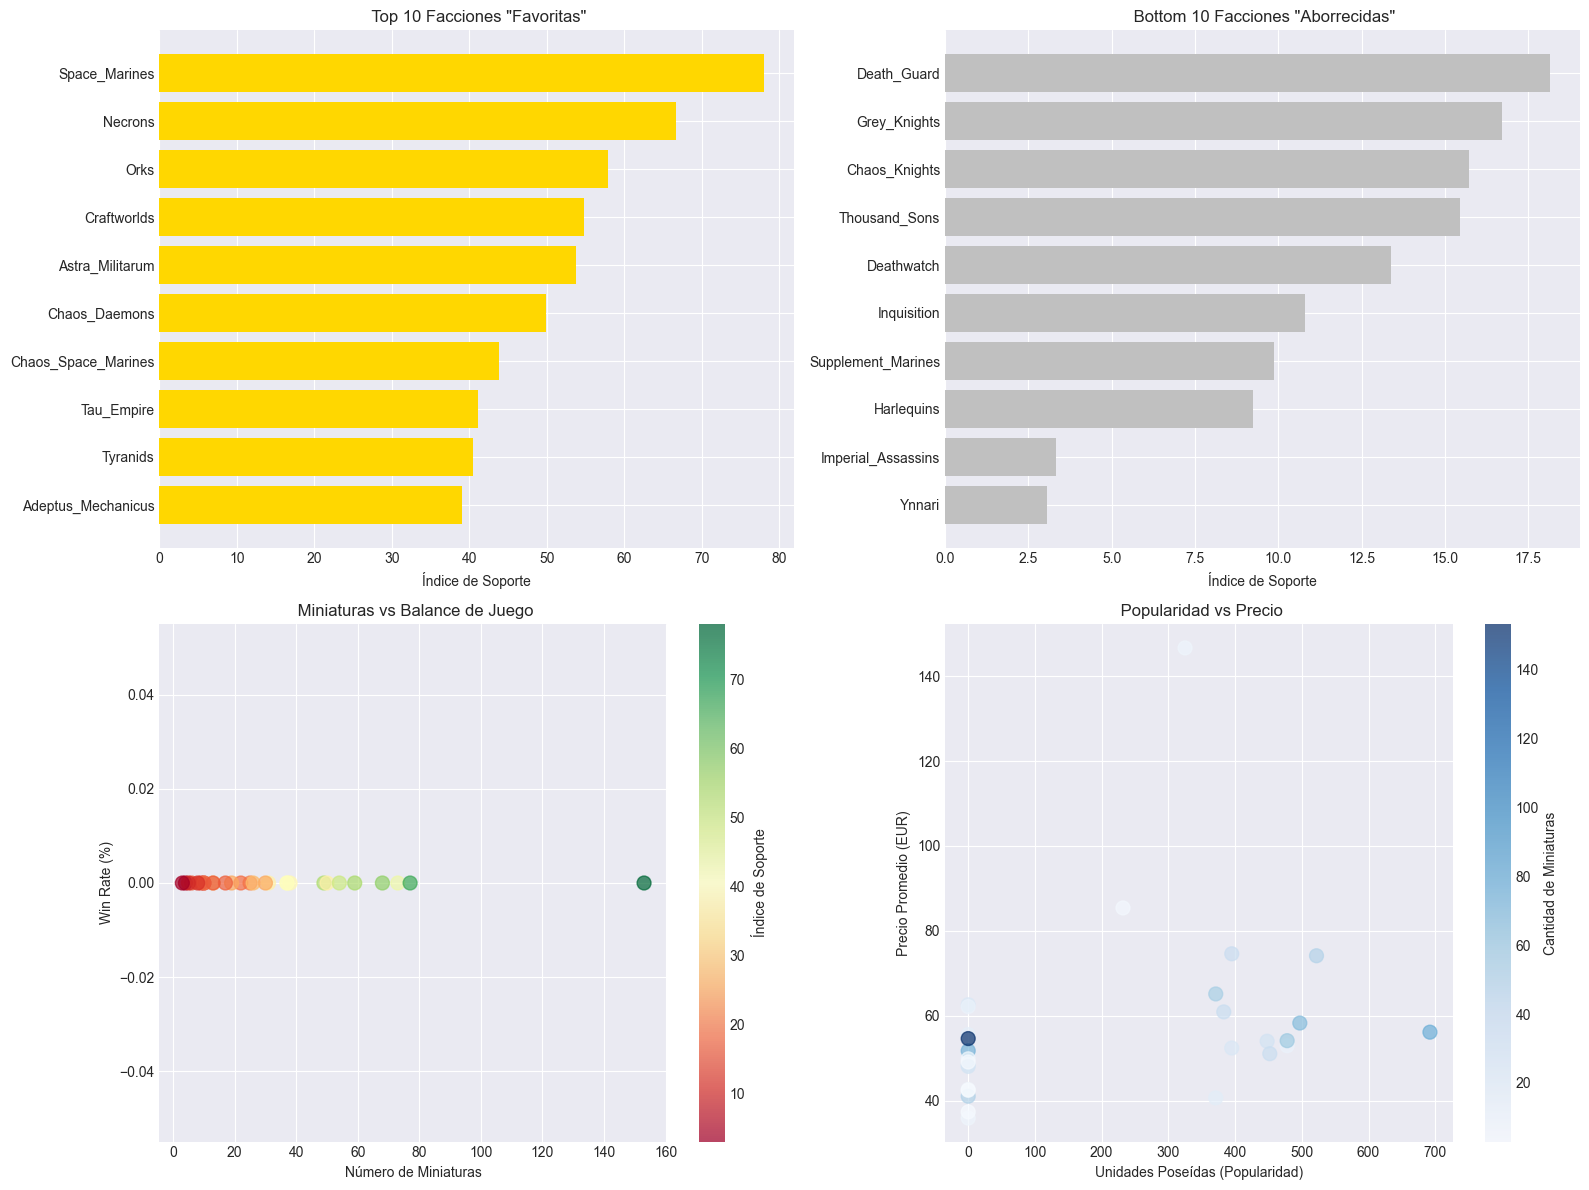

In [735]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top/Bottom por índice de soporte
sorted_factions = faction_support.sort_values('support_index', ascending=False)
axes[0, 0].barh(sorted_factions['faction'].head(10), sorted_factions['support_index'].head(10), color='gold')
axes[0, 0].set_title(' Top 10 Facciones "Favoritas"')
axes[0, 0].set_xlabel('Índice de Soporte')
axes[0, 0].invert_yaxis()

axes[0, 1].barh(sorted_factions['faction'].tail(10), sorted_factions['support_index'].tail(10), color='silver')
axes[0, 1].set_title(' Bottom 10 Facciones "Aborrecidas"')
axes[0, 1].set_xlabel('Índice de Soporte')
axes[0, 1].invert_yaxis()

# Relación entre miniaturas y win rate
scatter = axes[1, 0].scatter(
    faction_support['mini_count'], 
    faction_support['Win %'].fillna(0),
    c=faction_support['support_index'],
    cmap='RdYlGn', s=100, alpha=0.7
)
axes[1, 0].set_xlabel('Número de Miniaturas')
axes[1, 0].set_ylabel('Win Rate (%)')
axes[1, 0].set_title(' Miniaturas vs Balance de Juego')
plt.colorbar(scatter, ax=axes[1, 0], label='Índice de Soporte')

# Precio promedio vs popularidad (Owned)
scatter2 = axes[1, 1].scatter(
    faction_support['Owned'].fillna(0),
    faction_support['price_avg'],
    c=faction_support['mini_count'],
    cmap='Blues', s=100, alpha=0.7
)
axes[1, 1].set_xlabel('Unidades Poseídas (Popularidad)')
axes[1, 1].set_ylabel('Precio Promedio (EUR)')
axes[1, 1].set_title(' Popularidad vs Precio')
plt.colorbar(scatter2, ax=axes[1, 1], label='Cantidad de Miniaturas')

plt.tight_layout()
plt.savefig('hipotesis_3_faction_support.png', dpi=300, bbox_inches='tight')



In [736]:
# 3.5 - Resultados
print("\n RESULTADOS HIPÓTESIS 3:")
print("\n TOP 5 Facciones con Mayor Soporte:")
print(sorted_factions[['faction', 'mini_count', 'price_avg', 'support_index']].head().to_string(index=False))

print("\n BOTTOM 5 Facciones con Menor Soporte:")
print(sorted_factions[['faction', 'mini_count', 'price_avg', 'support_index']].tail().to_string(index=False))

# Test estadístico: ¿Hay diferencia significativa en win rate entre top/bottom?
top_factions = sorted_factions.nlargest(5, 'support_index')['Win %'].dropna()
bottom_factions = sorted_factions.nsmallest(5, 'support_index')['Win %'].dropna()

if len(top_factions) > 1 and len(bottom_factions) > 1:
    t_stat, p_val = stats.ttest_ind(top_factions, bottom_factions)
    print(f"\n Test T: Win Rate Top vs Bottom")
    print(f"   t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
    print(f"   {' Diferencia significativa' if p_val < 0.05 else '❌ Sin diferencia significativa'}")


 RESULTADOS HIPÓTESIS 3:

 TOP 5 Facciones con Mayor Soporte:
        faction  mini_count  price_avg  support_index
  Space_Marines         153      54.65          78.00
        Necrons          77      56.16          66.61
           Orks          68      58.31          57.92
    Craftworlds          59      54.16          54.85
Astra_Militarum          49      74.15          53.73

 BOTTOM 5 Facciones con Menor Soporte:
           faction  mini_count  price_avg  support_index
       Inquisition           8      42.66          10.79
Supplement_Marines           5      49.13           9.86
        Harlequins          10      35.93           9.25
Imperial_Assassins           4      37.38           3.32
            Ynnari           3      42.47           3.05


### HIPÓTESIS 4:
#### ¿Se pueden predecir acontecimientos del Lore en base a las colecciones de figuras?

In [737]:
# 4.1 - Preparar datos: libros por facción y año
lore_by_year = df_lore.groupby(['faction', 'year']).size().reset_index(name='book_count')

# 4.2 - Miniaturas por facción y año
minis_by_year = df_mini.groupby(['faction_clean', 'year']).size().reset_index(name='mini_count')

# 4.3 - Merge y análisis de correlación temporal
lore_mini_merge = pd.merge(
    lore_by_year,
    minis_by_year,
    left_on=['faction', 'year'],
    right_on=['faction_clean', 'year'],
    how='outer'
).fillna(0)

In [738]:
# 4.4 - Correlación Lore ↔ Miniaturas DENTRO de cada facción (CORREGIDO)
faction_correlations = []

for faction in df_lore['faction'].unique():
    subset = lore_mini_merge[lore_mini_merge['faction'] == faction]
    
    # Necesitamos suficientes puntos y varianza para calcular correlación
    if len(subset) > 2 and subset['book_count'].std() > 0 and subset['mini_count'].std() > 0:
        r, p = stats.pearsonr(subset['book_count'], subset['mini_count'])
        faction_correlations.append({
            'faction': faction,
            'correlation': r,
            'p_value': p,
            'n_years': len(subset),
            'significant': p < 0.05
        })

corr_df = pd.DataFrame(faction_correlations)

 Correlaciones INTRA-facción (Lore ↔ Miniaturas):
            faction  correlation  p_value  significant
         Tau_Empire         1.00     0.00         True
        Dark_Angels         0.56     0.24        False
       Space_Wolves         0.47     0.13        False
    Astra_Militarum         0.32     0.17        False
Chaos_Space_Marines        -0.26     0.36        False
               Orks        -0.24     0.61        False
      Chaos_Knights        -0.18     0.65        False
      Space_Marines        -0.17     0.49        False
        Inquisition        -0.17     0.72        False
            Necrons         0.15     0.81        False
       Blood_Angels        -0.03     0.95        False


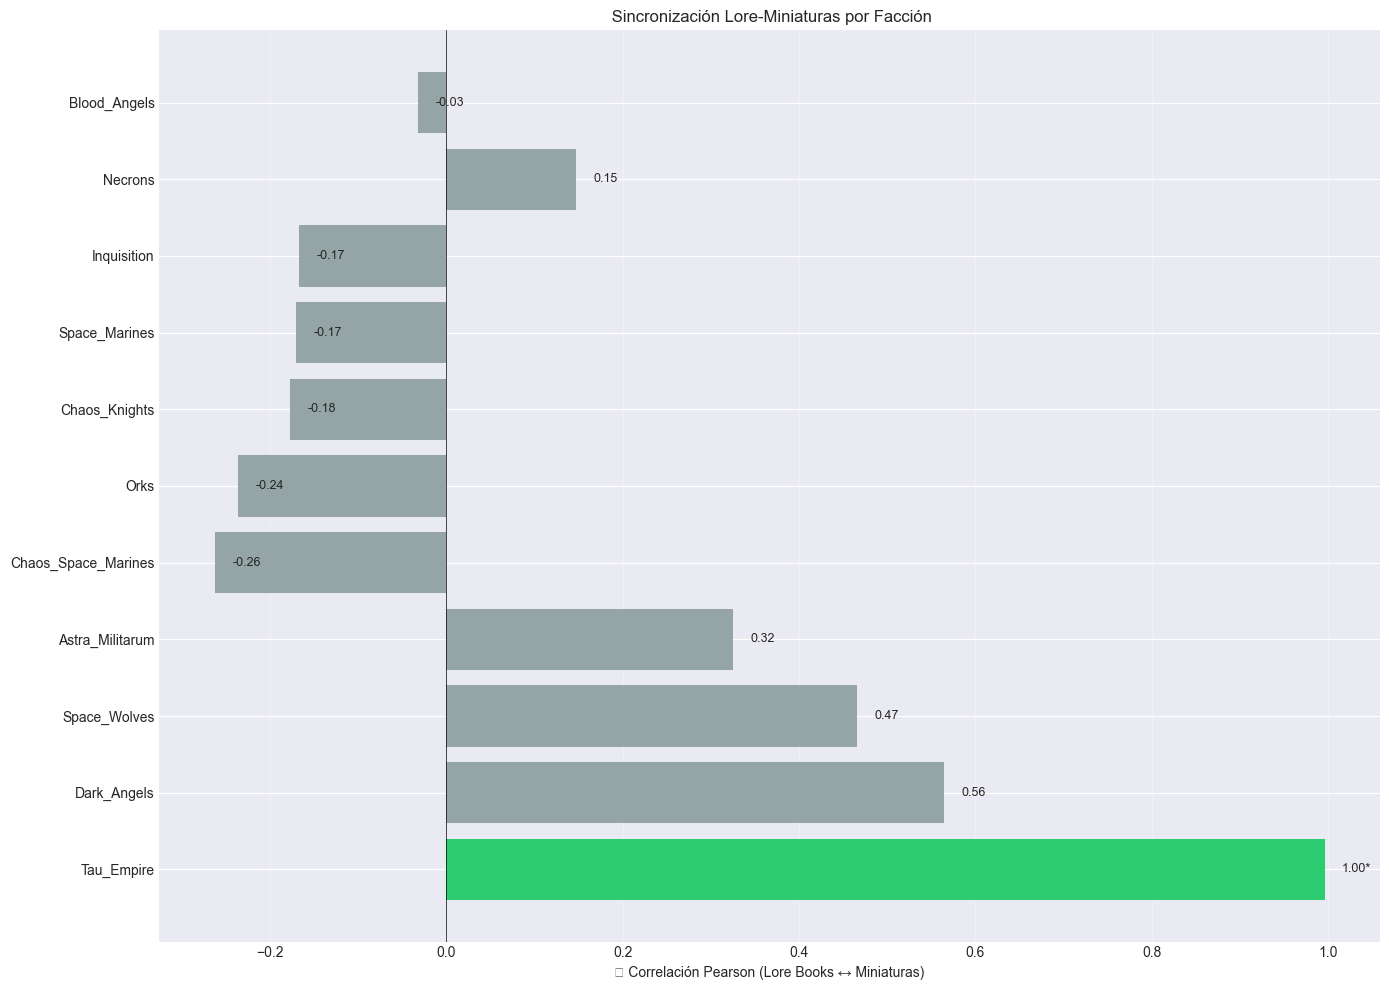

In [739]:
# 4.5 - Visualización:  Barras por facción
plt.figure(figsize=(14, 10))
valid_corr = corr_df.dropna(subset=['correlation']).sort_values('correlation', key=abs, ascending=False)

colors = ['#2ecc71' if row['significant'] else '#95a5a6' for _, row in valid_corr.iterrows()]
bars = plt.barh(valid_corr['faction'], valid_corr['correlation'], color=colors)

plt.xlabel('🔗 Correlación Pearson (Lore Books ↔ Miniaturas)')
plt.title(' Sincronización Lore-Miniaturas por Facción')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)

# Añadir valores y significancia
for bar, _, row in zip(bars, colors, valid_corr.itertuples()):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
             f"{row.correlation:.2f}{'*' if row.significant else ''}", 
             va='center', fontsize=9)

plt.tight_layout()
plt.savefig('hipotesis_4_intra_faction_corr.png', dpi=300, bbox_inches='tight')


print(" Correlaciones INTRA-facción (Lore ↔ Miniaturas):")
print(valid_corr[['faction', 'correlation', 'p_value', 'significant']].to_string(index=False))

In [740]:
# 4.6 - Ejemplo detallado: Space Marines
def analyze_lore_mini_sync(faction_name):
    """Analiza sincronización entre lanzamientos de lore y miniaturas"""
    faction_lore = df_lore[df_lore['faction'] == faction_name].groupby('year').size()
    faction_minis = df_mini[df_mini['faction_clean'] == faction_name].groupby('year').size()
    
    # Crear dataframe combinado
    years = sorted(set(faction_lore.index) | set(faction_minis.index))
    sync_df = pd.DataFrame({
        'year': years,
        'books': [faction_lore.get(y, 0) for y in years],
        'minis': [faction_minis.get(y, 0) for y in years]
    })
    # Gráfico de sincronización
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    ax1.bar(sync_df['year'], sync_df['minis'], alpha=0.6, label='Miniaturas', color='steelblue')
    ax1.set_xlabel('Año')
    ax1.set_ylabel('Número de Miniaturas', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    
    ax2 = ax1.twinx()
    ax2.plot(sync_df['year'], sync_df['books'], marker='o', color='crimson', linewidth=2, label='Libros Lore')
    ax2.set_ylabel('Número de Libros', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    
    plt.title(f' Sincronización Lore ↔ Miniaturas: {faction_name}')
    plt.grid(axis='x', alpha=0.3)
    
    # Añadir líneas para eventos notables
    peaks = sync_df[(sync_df['books'] > sync_df['books'].quantile(0.75)) | 
                    (sync_df['minis'] > sync_df['minis'].quantile(0.75))]
    for _, row in peaks.iterrows():
        ax1.axvline(row['year'], color='gray', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    return sync_df, fig

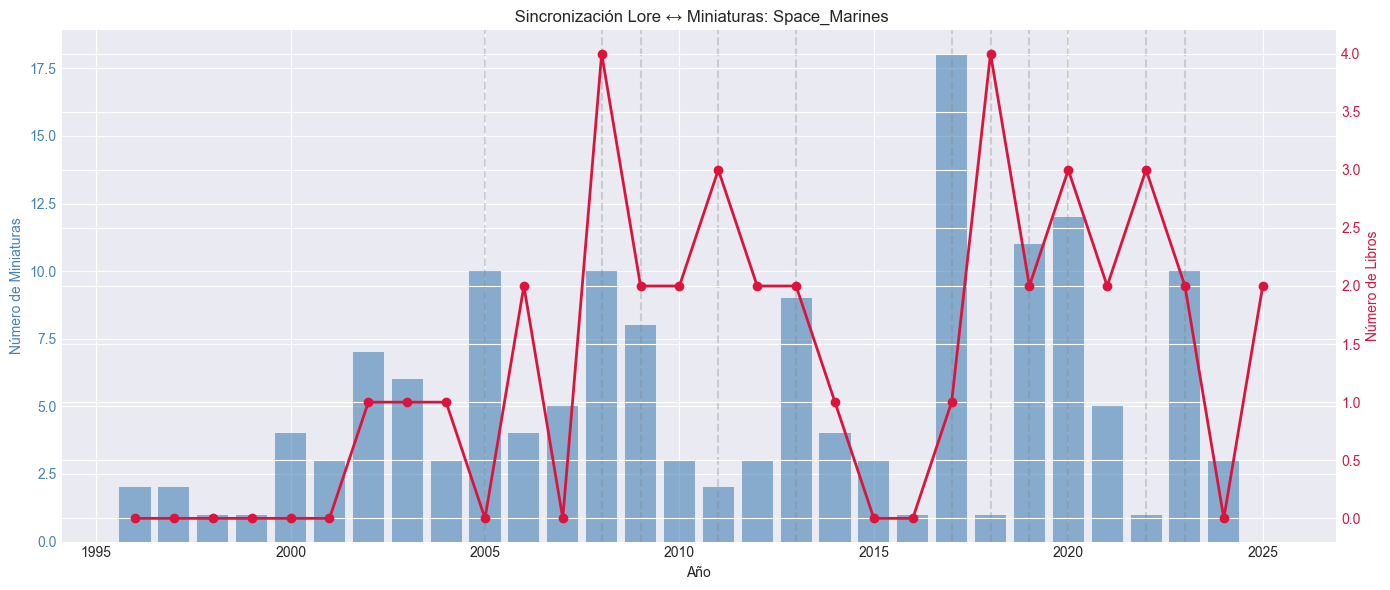

In [741]:
# Ejecutar para Space Marines
sm_sync, sm_fig = analyze_lore_mini_sync('Space_Marines')
sm_fig.savefig('hipotesis_4_space_marines_sync.png', dpi=300, bbox_inches='tight')


In [742]:
# 4.7 - Resultados
print("\n RESULTADOS HIPÓTESIS 4:")
print("\n Correlación Lore ↔ Miniaturas por Facción (Top 10):")
print(corr_df.sort_values('correlation', key=abs, ascending=False)
      .head(10)[['faction', 'correlation', 'p_value', 'n_years']]
      .to_string(index=False))

print("\n Interpretación:")
print("   • r > 0.5: Fuerte correlación positiva (lore impulsa miniaturas)")
print("   • r < -0.5: Correlación negativa (posible estrategia inversa)")
print("   • p < 0.05: Correlación estadísticamente significativa")


 RESULTADOS HIPÓTESIS 4:

 Correlación Lore ↔ Miniaturas por Facción (Top 10):
            faction  correlation  p_value  n_years
         Tau_Empire         1.00     0.00        7
        Dark_Angels         0.56     0.24        6
       Space_Wolves         0.47     0.13       12
    Astra_Militarum         0.32     0.17       19
Chaos_Space_Marines        -0.26     0.36       14
               Orks        -0.24     0.61        7
      Chaos_Knights        -0.18     0.65        9
      Space_Marines        -0.17     0.49       19
        Inquisition        -0.17     0.72        7
            Necrons         0.15     0.81        5

 Interpretación:
   • r > 0.5: Fuerte correlación positiva (lore impulsa miniaturas)
   • r < -0.5: Correlación negativa (posible estrategia inversa)
   • p < 0.05: Correlación estadísticamente significativa


In [743]:
# 4.5 - NUEVO: Correlación TEMPORAL ENTRE facciones
# Idea: ¿Se lanzan miniaturas/libros de facciones A y B en los mismos años?

# Crear matriz año × facción para libros
lore_matrix = df_lore.pivot_table(
    index='year', 
    columns='faction', 
    values='titulo', 
    aggfunc='count', 
    fill_value=0
)

# Crear matriz año × facción para miniaturas  
mini_matrix = df_mini.pivot_table(
    index='year', 
    columns='faction_clean', 
    values='mini', 
    aggfunc='count', 
    fill_value=0
)

In [744]:
# Alinear índices (años comunes)
common_years = sorted(set(lore_matrix.index) & set(mini_matrix.index))
print(f"Años comunes: {len(common_years)}")

Años comunes: 26


In [745]:
if len(common_years) == 0:
    print("❌ No hay años en común entre df_lore y df_mini")
    print(f"Rango lore: {lore_matrix.index.min()} - {lore_matrix.index.max()}")
    print(f"Rango mini: {mini_matrix.index.min()} - {mini_matrix.index.max()}")
else:
    lore_matrix = lore_matrix.loc[common_years]
    mini_matrix = mini_matrix.loc[common_years]
    
# Normalizar manejando la división por cero
lore_max = lore_matrix.max().replace(0, 1)
mini_max = mini_matrix.max().replace(0, 1)

lore_norm = lore_matrix.div(lore_max, axis=1)
mini_norm = mini_matrix.div(mini_max, axis=1)

# activity_matrix: promedio de actividad lore y mini (0 si no hay datos)
activity_matrix = (lore_norm + mini_norm) / 2

# Llenar cualquier NaN residual con 0
activity_matrix = activity_matrix.fillna(0)

print(f" Años analizados: {len(common_years)} ({min(common_years)}-{max(common_years)})")
print(f"  Facciones con datos: {activity_matrix.shape[1]}")
print(activity_matrix.head())

 Años analizados: 26 (1999-2024)
  Facciones con datos: 29
faction  Adepta_Sororitas  Adeptus_Custodes  Adeptus_Mechanicus  \
year                                                              
1999                 0.00              0.00                0.00   
2000                 0.00              0.00                0.00   
2001                 0.00              0.00                0.00   
2002                 0.00              0.00                0.00   
2003                 0.03              0.00                0.03   

faction  Astra_Militarum  Black_Templars  Blood_Angels  Chaos_Daemons  \
year                                                                    
1999                0.04            0.00          0.00           0.00   
2000                0.08            0.00          0.00           0.00   
2001                0.33            0.00          0.00           0.00   
2002                0.17            0.00          0.07           0.00   
2003                0.58         

In [747]:
# 4.6 - Calcular correlación de patrones temporales entre facciones
faction_pairs_corr = []
factions = activity_matrix.columns.tolist()

for i, fac1 in enumerate(factions):
    for fac2 in factions[i+1:]:
        # Solo calcular si ambas tienen varianza suficiente
        if activity_matrix[fac1].std() > 0 and activity_matrix[fac2].std() > 0:
            r, p = stats.pearsonr(activity_matrix[fac1], activity_matrix[fac2])
            faction_pairs_corr.append({
                'faction_1': fac1,
                'faction_2': fac2,
                'correlation': r,
                'p_value': p,
                'significant': p < 0.05
            })

pairs_df = pd.DataFrame(faction_pairs_corr)

In [748]:
pairs_df

,faction_1,faction_2,correlation,p_value,significant
0,Adepta_Sororitas,Adeptus_Custodes,0.14,0.51,False
1,Adepta_Sororitas,Adeptus_Mechanicus,0.04,0.83,False
2,Adepta_Sororitas,Astra_Militarum,-0.19,0.35,False
3,Adepta_Sororitas,Blood_Angels,-0.03,0.89,False
4,Adepta_Sororitas,Chaos_Daemons,-0.24,0.24,False
...,...,...,...,...,...
373,Tau_Empire,Tyranids,-0.13,0.54,False
374,Tau_Empire,Ynnari,0.11,0.59,False
375,Thousand_Sons,Tyranids,-0.15,0.47,False
376,Thousand_Sons,Ynnari,0.26,0.20,False


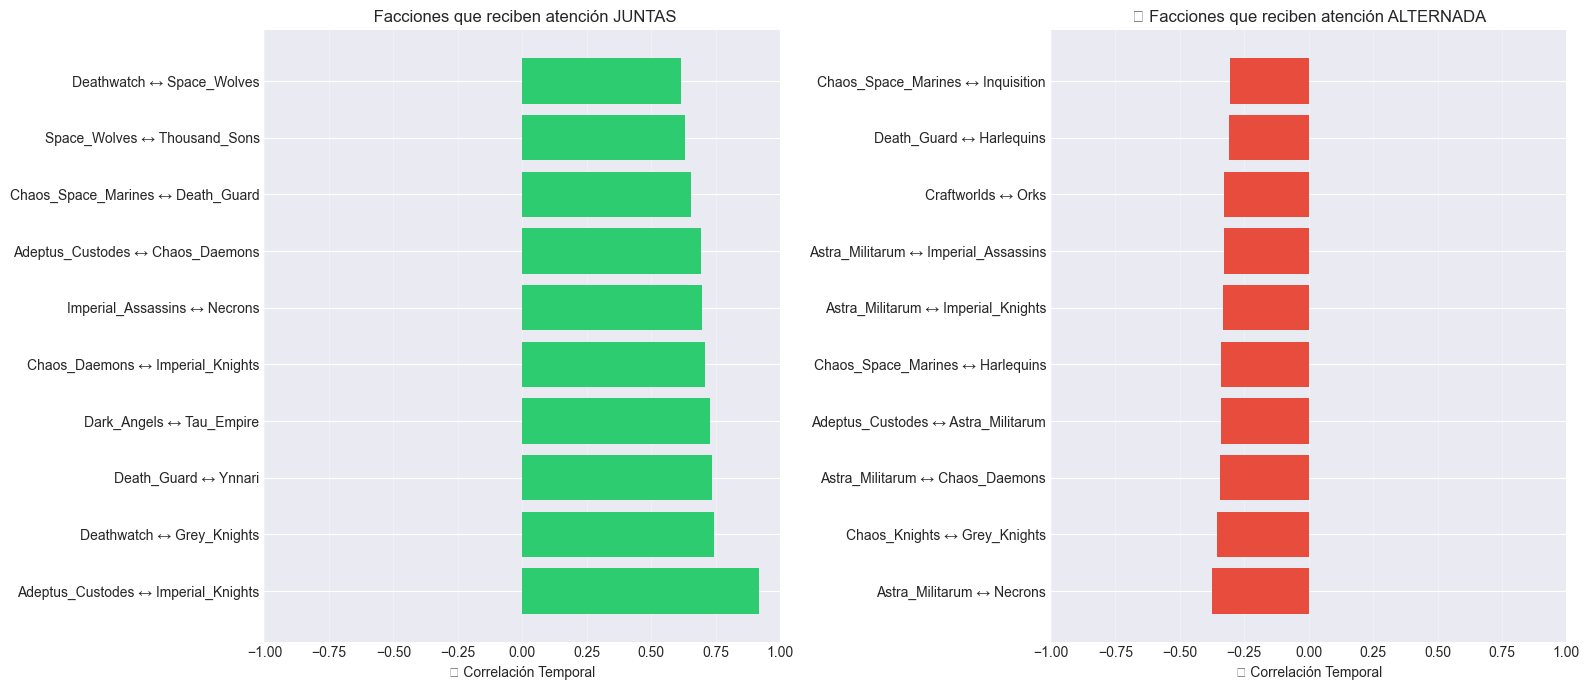

In [749]:
# 4.7 - Visualizar TOP correlaciones positivas y negativas
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 correlaciones POSITIVAS (se mueven juntas)
top_positive = pairs_df.nlargest(10, 'correlation')
axes[0].barh(top_positive['faction_1'] + ' ↔ ' + top_positive['faction_2'], 
             top_positive['correlation'], color='#2ecc71')
axes[0].set_xlabel('🔗 Correlación Temporal')
axes[0].set_title(' Facciones que reciben atención JUNTAS')
axes[0].set_xlim(-1, 1)
axes[0].grid(axis='x', alpha=0.3)

# Top 10 correlaciones NEGATIVAS (se mueven opuestas)
top_negative = pairs_df.nsmallest(10, 'correlation')
axes[1].barh(top_negative['faction_1'] + ' ↔ ' + top_negative['faction_2'], 
             top_negative['correlation'], color='#e74c3c')
axes[1].set_xlabel('🔗 Correlación Temporal')
axes[1].set_title('❌ Facciones que reciben atención ALTERNADA')
axes[1].set_xlim(-1, 1)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('hipotesis_4_inter_faction_corr.png', dpi=300, bbox_inches='tight')


In [750]:
print("Facciones en df_lore:", df_lore['faction'].nunique())
print("Facciones en df_mini:", df_mini['faction_clean'].nunique())

Facciones en df_lore: 30
Facciones en df_mini: 28


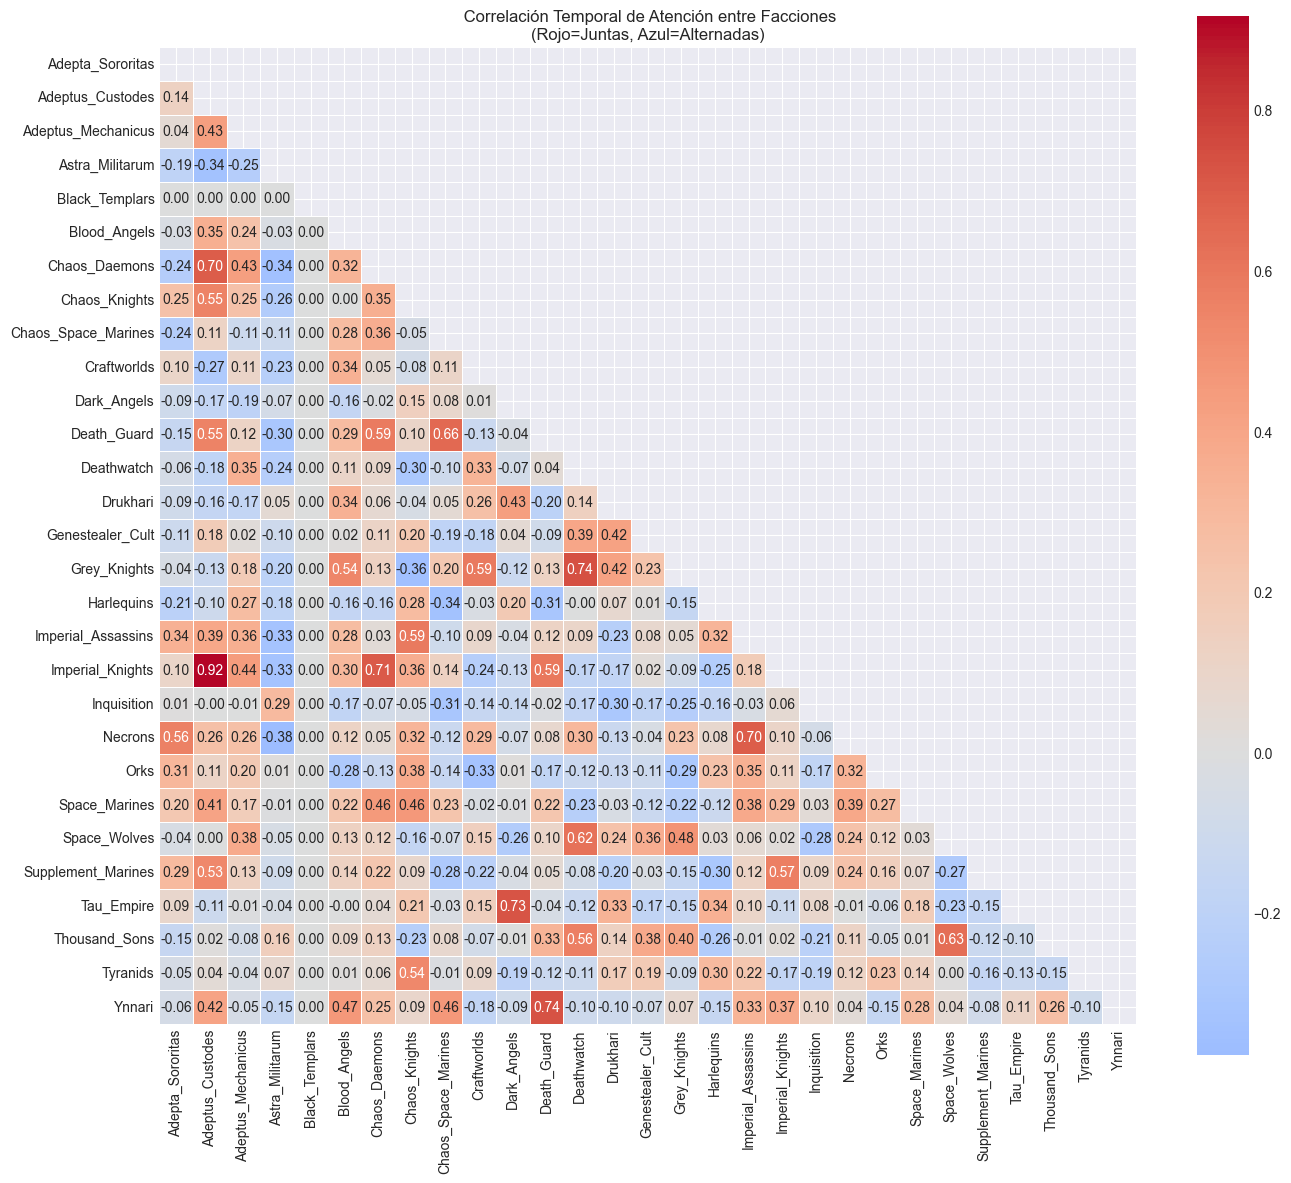

In [751]:

# 4.8 - Heatmap de correlaciones (matriz completa)
# Crear matriz simétrica para heatmap
corr_matrix = pd.DataFrame(np.eye(len(factions)), index=factions, columns=factions)

for _, row in pairs_df.iterrows():
    corr_matrix.loc[row['faction_1'], row['faction_2']] = row['correlation']
    corr_matrix.loc[row['faction_2'], row['faction_1']] = row['correlation']

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title(' Correlación Temporal de Atención entre Facciones\n(Rojo=Juntas, Azul=Alternadas)')
plt.tight_layout()
plt.savefig('hipotesis_4_correlation_matrix.png', dpi=300, bbox_inches='tight')



###  HIPÓTESIS 5:
#### ¿Está balanceado el juego? ¿Existe un meta?

In [752]:
# 5.1 - Preparar datos de balance
balance_df = df_faction.copy()

# Limpiar y convertir columnas numéricas
for col in ['Win %', 'Real Win %', 'VP', 'Opp VP', 'Owned', 'Primary']:
    balance_df[col] = pd.to_numeric(balance_df[col].astype(str).str.replace(',', '.'), errors='coerce')

In [753]:
# 5.2 - Calcular métricas de balance
balance_df['vp_diff'] = balance_df['VP'] - balance_df['Opp VP']  # Diferencial de puntos
balance_df['popularity_ratio'] = balance_df['Owned'] / balance_df['Owned'].sum()  # Popularidad relativa
balance_df['performance_index'] = (
    balance_df['Real Win %'] * 0.6 +  # Peso mayor al win rate real
    balance_df['vp_diff'] * 0.2 +
    (1 - balance_df['popularity_ratio']) * 20 * 0.2  # Bonus por ser menos popular
)

In [754]:
# 5.3 - Clasificar facciones por estado de balance
balance_df['balance_status'] = pd.cut(
    balance_df['performance_index'],
    bins=[0, 45, 55, 100],
    labels=['Underpowered ', 'Balanced ', 'Overpowered ']
)

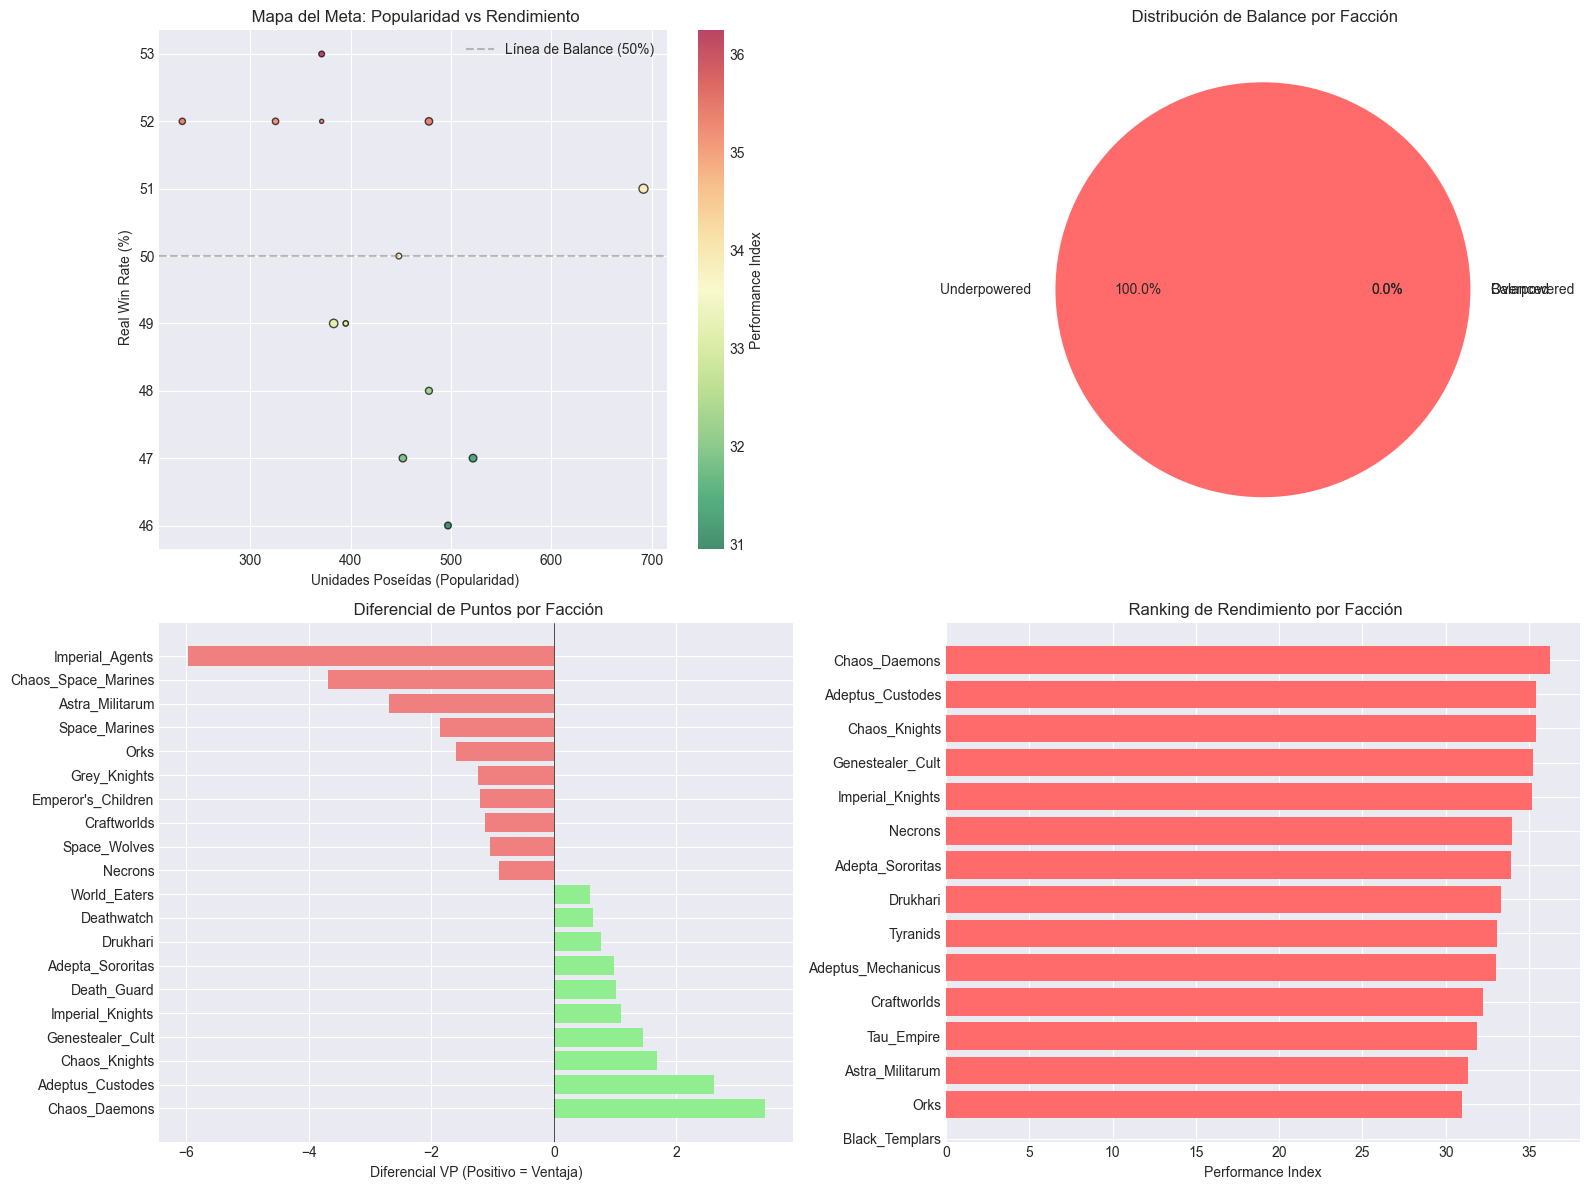

In [755]:
# 5.4 - Visualización del meta actual
fig, axes = plt.subplots(2, 2, figsize=(16, 12), squeeze=False)

scatter = axes[0, 0].scatter(
    balance_df['Owned'].fillna(0),
    balance_df['Real Win %'],
    c=balance_df['performance_index'],
    cmap='RdYlGn_r', s=balance_df['Games']/1000, alpha=0.7, edgecolors='black'
)
axes[0, 0].set_xlabel(' Unidades Poseídas (Popularidad)')
axes[0, 0].set_ylabel(' Real Win Rate (%)')
axes[0, 0].set_title(' Mapa del Meta: Popularidad vs Rendimiento')
axes[0, 0].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Línea de Balance (50%)')
axes[0, 0].legend()
plt.colorbar(scatter, ax=axes[0, 0], label='Performance Index')

# Distribución de estados de balance
balance_counts = balance_df['balance_status'].value_counts()
axes[0, 1].pie(balance_counts, labels=balance_counts.index, autopct='%1.1f%%', 
               colors=['#ff6b6b', '#4ecdc4', '#ffa502'])
axes[0, 1].set_title(' Distribución de Balance por Facción')

# VP Differential por facción
sorted_vp = balance_df.sort_values('vp_diff', ascending=False)
axes[1, 0].barh(sorted_vp['faction_clean'].head(10), sorted_vp['vp_diff'].head(10), color='lightgreen')
axes[1, 0].barh(sorted_vp['faction_clean'].tail(10), sorted_vp['vp_diff'].tail(10), color='lightcoral')
axes[1, 0].axvline(x=0, color='black', linewidth=0.5)
axes[1, 0].set_xlabel('Diferencial VP (Positivo = Ventaja)')
axes[1, 0].set_title(' Diferencial de Puntos por Facción')

sorted_balance = balance_df.sort_values('performance_index', ascending=False)
color_map = {
    'Underpowered ': '#ff6b6b',
    'Balanced ': '#4ecdc4', 
    'Overpowered ': '#ffa502'
}

# Usar lista por comprensión para evitar el problema de Categorical
status_values = sorted_balance['balance_status'].head(15)
colors = [color_map.get(s, '#95a5a6') for s in status_values]

axes[1, 1].barh(sorted_balance['faction_clean'].head(15), 
                sorted_balance['performance_index'].head(15),
                color=colors)
axes[1, 1].set_xlabel('Performance Index')
axes[1, 1].set_title(' Ranking de Rendimiento por Facción')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('hipotesis_5_game_balance.png', dpi=300, bbox_inches='tight')


In [756]:
# 5.5 - Análisis estadístico de balance
print("\n RESULTADOS HIPÓTESIS 5 - Balance del Juego:")
print(f"\n Estadísticas de Win Rate:")
print(f"   Media: {balance_df['Real Win %'].mean():.2f}%")
print(f"   Desviación: {balance_df['Real Win %'].std():.2f}%")
print(f"   Rango: {balance_df['Real Win %'].min():.2f}% - {balance_df['Real Win %'].max():.2f}%")

print(f"\n Distribución de Balance:")
for status in balance_df['balance_status'].unique():
    count = balance_df[balance_df['balance_status'] == status].shape[0]
    factions = balance_df[balance_df['balance_status'] == status]['faction_clean'].tolist()
    print(f"   {status}: {count} facciones - {', '.join(factions[:3])}{'...' if len(factions)>3 else ''}")


 RESULTADOS HIPÓTESIS 5 - Balance del Juego:

 Estadísticas de Win Rate:
   Media: 48.75%
   Desviación: 2.38%
   Rango: 43.00% - 53.00%

 Distribución de Balance:
   Underpowered : 14 facciones - Adepta_Sororitas, Adeptus_Custodes, Adeptus_Mechanicus...
   nan: 0 facciones - 


In [757]:
win_rates = balance_df['Real Win %'].dropna()
stat, p_normal = stats.normaltest(win_rates)
print(f"\n Test de Normalidad (Win Rate):")
print(f"   p-value: {p_normal:.4f} - {' Distribución normal' if p_normal > 0.05 else '❌ No normal'}")


 Test de Normalidad (Win Rate):
   p-value: 0.5727 -  Distribución normal


### HIPÓTESIS 6:
#### ¿Existe relación entre el poder de una figura y su precio? ¿Se puede predecir?

In [758]:
# 6.1 - Preparar datos: usar 'cost' como proxy de poder
power_price_df = df_mini[['mini', 'faction_clean', 'cost', 'price', 'year', 'material']].dropna(subset=['cost', 'price'])

In [759]:
# 6.2 - Análisis de correlación
correlation_power_price = power_price_df['cost'].corr(power_price_df['price'])
print(f"🔗 Correlación Poder (cost) ↔ Precio: {correlation_power_price:.3f}")

🔗 Correlación Poder (cost) ↔ Precio: 0.742


In [760]:
# 6.3 - Modelo de regresión lineal simple
X = power_price_df[['cost']]
y = power_price_df['price']

model = LinearRegression()
model.fit(X, y)
r_squared = model.score(X, y)

print(f" Modelo: Precio = {model.intercept_:.2f} + {model.coef_[0]:.2f} * Cost")
print(f" R² del modelo: {r_squared:.3f}")

 Modelo: Precio = 27.82 + 0.24 * Cost
 R² del modelo: 0.551


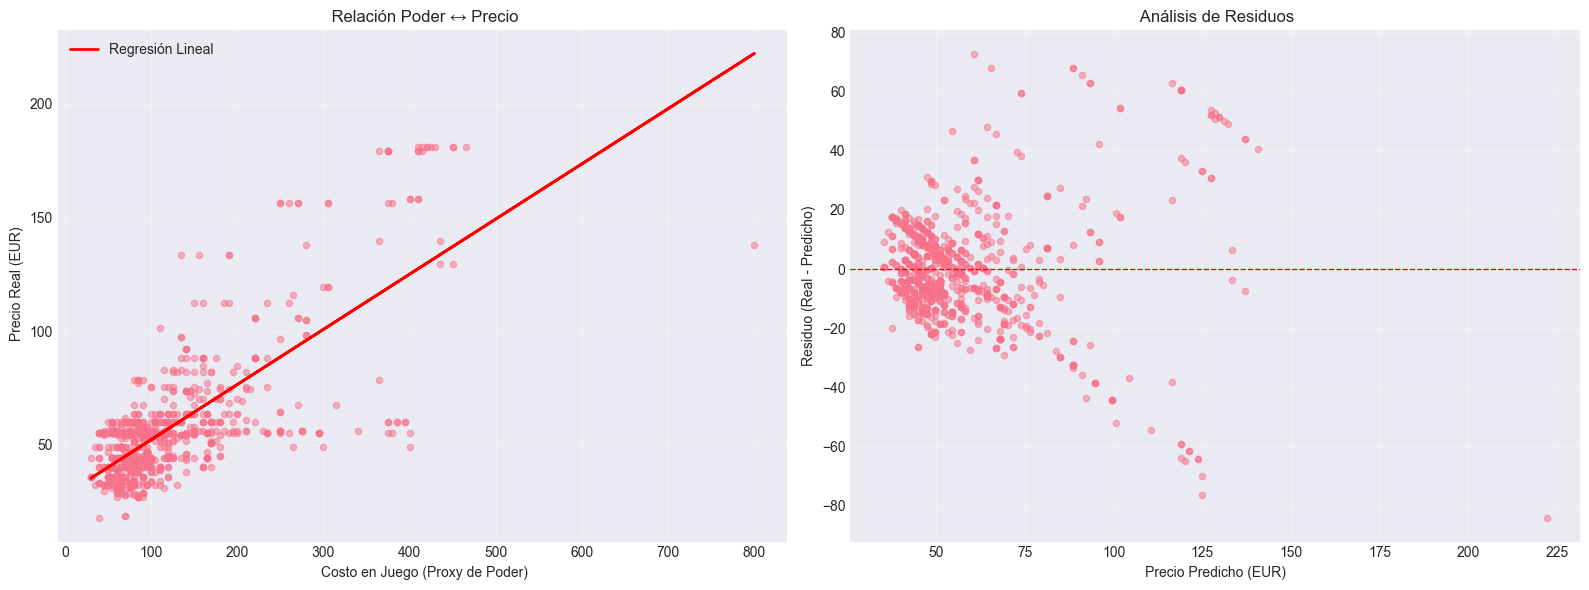

In [761]:
# 6.4 - Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter con línea de regresión
axes[0].scatter(power_price_df['cost'], power_price_df['price'], alpha=0.5, s=20)
axes[0].plot(power_price_df['cost'], model.predict(X), color='red', linewidth=2, label='Regresión Lineal')
axes[0].set_xlabel(' Costo en Juego (Proxy de Poder)')
axes[0].set_ylabel(' Precio Real (EUR)')
axes[0].set_title(' Relación Poder ↔ Precio')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuos del modelo (para evaluar calidad predictiva)
power_price_df['predicted_price'] = model.predict(X)
power_price_df['residual'] = power_price_df['price'] - power_price_df['predicted_price']

axes[1].scatter(power_price_df['predicted_price'], power_price_df['residual'], alpha=0.5, s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Precio Predicho (EUR)')
axes[1].set_ylabel('Residuo (Real - Predicho)')
axes[1].set_title(' Análisis de Residuos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hipotesis_6_power_price.png', dpi=300, bbox_inches='tight')


In [762]:
# 6.5 - Función predictiva
def predict_mini_price(cost_value, faction=None, material=None):
    """
    Predice el precio de una miniatura basado en su costo en juego.
    Ajustes opcionales por facción/material (heurísticos).
    """
    base_price = model.intercept_ + model.coef_[0] * cost_value
    
    # Ajustes heurísticos (basados en promedios observados)
    if faction and faction in df_mini['faction_clean'].unique():
        faction_avg = df_mini[df_mini['faction_clean'] == faction]['price'].mean()
        global_avg = df_mini['price'].mean()
        base_price *= faction_avg / global_avg if pd.notna(faction_avg) else 1
    
    if material and material in df_mini['material'].unique():
        material_avg = df_mini[df_mini['material'] == material]['price'].mean()
        global_avg = df_mini['price'].mean()
        base_price *= material_avg / global_avg if pd.notna(material_avg) else 1
    
    return max(0, base_price)  # Precio no negativo

# Ejemplos de predicción
print("\n Ejemplos de Predicción de Precios:")
test_costs = [50, 100, 150, 200]
for cost in test_costs:
    pred = predict_mini_price(cost)
    print(f"   Costo {cost:3d} pts → Precio estimado: {pred:.2f} EUR")


 Ejemplos de Predicción de Precios:
   Costo  50 pts → Precio estimado: 39.97 EUR
   Costo 100 pts → Precio estimado: 52.12 EUR
   Costo 150 pts → Precio estimado: 64.27 EUR
   Costo 200 pts → Precio estimado: 76.42 EUR


In [763]:
# 6.6 - Evaluación por rangos de poder
power_price_df['power_tier'] = pd.cut(
    power_price_df['cost'],
    bins=[0, 50, 100, 150, 200, 1000],
    labels=['T1: Básico', 'T2: Común', 'T3: Épico', 'T4: Legendario', 'T5: Único']
)

tier_analysis = power_price_df.groupby('power_tier').agg({
    'cost': ['mean', 'std'],
    'price': ['mean', 'std', 'count']
}).round(2)

print("\n Análisis por Tier de Poder:")
print(tier_analysis)


 Análisis por Tier de Poder:
                 cost        price            
                 mean   std   mean   std count
power_tier                                    
T1: Básico      45.00  5.71  41.68 10.17    70
T2: Común       77.78 13.57  46.69 10.31   494
T3: Épico      125.70 14.16  58.92 15.49   172
T4: Legendario 173.45 12.97  65.45 20.39    87
T5: Único      314.09 90.82 105.17 47.93   104


### 📖 HIPÓTESIS 7:
#### ¿Existe relación entre el número de entradas del Lore de una figura y su precio?

In [764]:
# 7.1 - Contar entradas de lore por facción
lore_counts = df_lore.groupby('faction').agg({
    'titulo': 'count',
    'serie': 'nunique',
    'year': ['min', 'max']
}).reset_index()
lore_counts.columns = ['faction', 'book_count', 'series_count', 'first_book', 'last_book']
lore_counts['lore_span'] = lore_counts['last_book'] - lore_counts['first_book'] + 1

In [765]:
# 7.2 - Merge con precios de miniaturas
faction_avg_price = df_mini.groupby('faction_clean')['price'].agg(['mean', 'median', 'count']).reset_index()
faction_avg_price.columns = ['faction', 'price_mean', 'price_median', 'mini_count']

lore_price_merge = pd.merge(
    lore_counts,
    faction_avg_price,
    left_on='faction',
    right_on='faction',
    how='inner'
)

In [766]:
# 7.3 - Calcular correlaciones
correlations = {
    'books_vs_price': lore_price_merge['book_count'].corr(lore_price_merge['price_mean']),
    'series_vs_price': lore_price_merge['series_count'].corr(lore_price_merge['price_mean']),
    'lore_span_vs_price': lore_price_merge['lore_span'].corr(lore_price_merge['price_mean'])
}

print("🔗 Correlaciones Lore ↔ Precio:")
for key, value in correlations.items():
    print(f"   {key}: {value:.3f}")

🔗 Correlaciones Lore ↔ Precio:
   books_vs_price: -0.002
   series_vs_price: 0.025
   lore_span_vs_price: -0.143


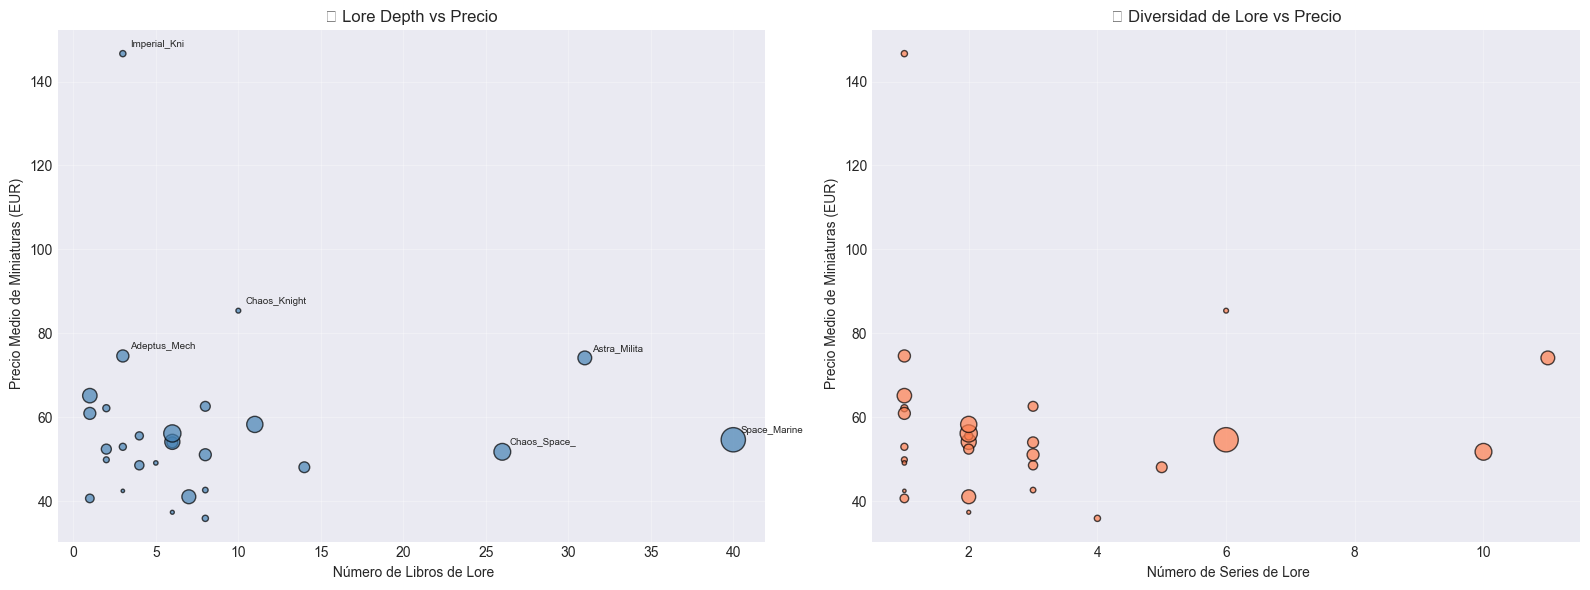

In [767]:
# 7.4 - Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Books vs Precio Medio
axes[0].scatter(lore_price_merge['book_count'], lore_price_merge['price_mean'], 
                s=lore_price_merge['mini_count']*2, alpha=0.7, c='steelblue', edgecolors='black')
axes[0].set_xlabel(' Número de Libros de Lore')
axes[0].set_ylabel(' Precio Medio de Miniaturas (EUR)')
axes[0].set_title('📖 Lore Depth vs Precio')
axes[0].grid(alpha=0.3)

# Añadir etiquetas para outliers
for _, row in lore_price_merge.iterrows():
    if row['book_count'] > lore_price_merge['book_count'].quantile(0.9) or \
       row['price_mean'] > lore_price_merge['price_mean'].quantile(0.9):
        axes[0].annotate(row['faction'][:12], (row['book_count'], row['price_mean']), 
                        fontsize=7, xytext=(5, 5), textcoords='offset points')

# Series vs Precio (diversidad de lore)
axes[1].scatter(lore_price_merge['series_count'], lore_price_merge['price_mean'], 
                s=lore_price_merge['mini_count']*2, alpha=0.7, c='coral', edgecolors='black')
axes[1].set_xlabel(' Número de Series de Lore')
axes[1].set_ylabel(' Precio Medio de Miniaturas (EUR)')
axes[1].set_title('🎭 Diversidad de Lore vs Precio')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hipotesis_7_lore_price.png', dpi=300, bbox_inches='tight')


In [768]:
# 7.5 - Análisis por facciones destacadas
print("\n RESULTADOS HIPÓTESIS 7:")
print("\n Top Facciones por Profundidad de Lore:")
top_lore = lore_price_merge.nlargest(10, 'book_count')[['faction', 'book_count', 'price_mean', 'mini_count']]
print(top_lore.to_string(index=False))

print("\n Facciones con Mayor Precio vs Lore:")
lore_price_merge['price_per_book'] = lore_price_merge['price_mean'] / (lore_price_merge['book_count'] + 1)
sorted_by_efficiency = lore_price_merge.sort_values('price_per_book', ascending=False)
print(sorted_by_efficiency[['faction', 'book_count', 'price_mean', 'price_per_book']].head(10).to_string(index=False))


 RESULTADOS HIPÓTESIS 7:

 Top Facciones por Profundidad de Lore:
            faction  book_count  price_mean  mini_count
      Space_Marines          40       54.65         153
    Astra_Militarum          31       74.15          49
Chaos_Space_Marines          26       51.78          73
       Space_Wolves          14       48.10          30
               Orks          11       58.31          68
      Chaos_Knights          10       85.41           6
        Dark_Angels           8       62.62          25
         Harlequins           8       35.93          10
        Inquisition           8       42.66           8
         Tau_Empire           8       51.08          37

 Facciones con Mayor Precio vs Lore:
           faction  book_count  price_mean  price_per_book
  Imperial_Knights           3      146.65           36.66
     Chaos_Daemons           1       65.16           32.58
          Tyranids           1       60.93           30.47
     Thousand_Sons           2       62.17 

In [769]:
# 7.6 - Conclusión estadística
r_books_price, p_books_price = stats.pearsonr(
    lore_price_merge['book_count'], 
    lore_price_merge['price_mean']
)
print(f"\n Test Estadístico (Books ↔ Price):")
print(f"   Pearson r = {r_books_price:.3f}, p-value = {p_books_price:.4f}")
print(f"   {' Correlación significativa' if p_books_price < 0.05 else '❌ Sin correlación significativa'}")


 Test Estadístico (Books ↔ Price):
   Pearson r = -0.002, p-value = 0.9901
   ❌ Sin correlación significativa



### HIPÓTESIS 8: Power Creep Analysis
#### ¿Las miniaturas nuevas son "más fuertes por el mismo costo"?


In [770]:
# 8.1 - Preparación de datos: limpiar y normalizar
df_pc = df_mini.copy()
df_pc['year'] = pd.to_numeric(df_pc['year'], errors='coerce')
df_pc['cost'] = pd.to_numeric(df_pc['cost'], errors='coerce')
df_pc['price'] = pd.to_numeric(df_pc['price'], errors='coerce')

# Eliminar filas sin datos esenciales
df_pc = df_pc.dropna(subset=['year', 'cost', 'faction_clean']).copy()

In [771]:
# 8.2 - Métrica clave: "Eficiencia de Poder" = cost / price
# Mayor valor = más puntos de juego por euro = posible power creep
df_pc['power_efficiency'] = df_pc['cost'] / df_pc['price']

In [772]:
# 8.3 - Agrupar por década para análisis macro
df_pc['decade'] = (df_pc['year'] // 10) * 10

In [773]:
# Estadísticas por década
decade_stats = df_pc.groupby('decade').agg({
    'cost': ['mean', 'median', 'std'],
    'price': ['mean', 'median'],
    'power_efficiency': ['mean', 'median'],
    'mini': 'count'
}).round(2)

print(" Evolución de Costo y Eficiencia por Década:")
decade_stats

 Evolución de Costo y Eficiencia por Década:


cost              price        power_efficiency         mini
         mean median   std  mean median             mean median count
decade                                                               
1990   114.36  95.00 63.22 52.25  52.90             2.18   2.12    47
2000   118.62  85.00 98.31 58.12  51.06             1.97   1.90   210
2010   125.54  95.00 83.36 57.45  54.28             2.19   2.01   498
2020   105.29  80.00 65.31 55.12  55.20             1.92   1.66   171

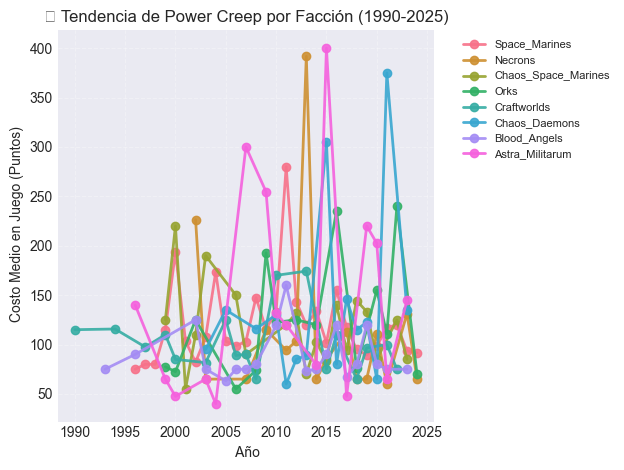

In [774]:
# 8.4 - Visualización 1: Tendencia de costo medio por año (por facción top)plt.figure(figsize=(14, 7))
# Seleccionar facciones con suficiente data
top_factions = df_pc['faction_clean'].value_counts().nlargest(8).index
colors = sns.color_palette("husl", len(top_factions))

for idx, faction in enumerate(top_factions):
    faction_data = df_pc[df_pc['faction_clean'] == faction].groupby('year')['cost'].mean().reset_index()
    if len(faction_data) >= 3:  # Mínimo para trazar línea
        plt.plot(faction_data['year'], faction_data['cost'], 
                marker='o', label=faction, color=colors[idx], linewidth=2, alpha=0.9)

plt.xlabel(' Año')
plt.ylabel(' Costo Medio en Juego (Puntos)')
plt.title('🔺 Tendencia de Power Creep por Facción (1990-2025)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('hipotesis_8_power_creep_trend.png', dpi=300, bbox_inches='tight')



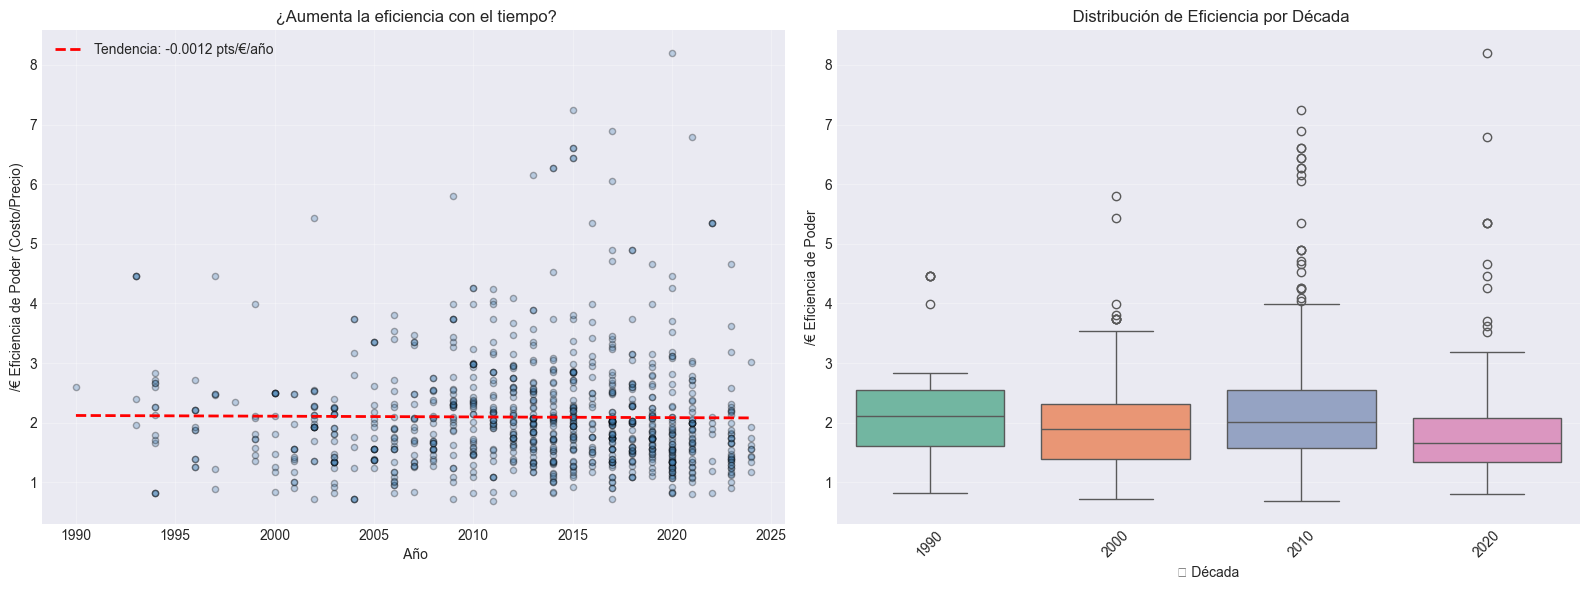

In [775]:
# 8.5 - Visualización 2: Eficiencia de Poder (cost/price) over time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter global con línea de tendencia
axes[0].scatter(df_pc['year'], df_pc['power_efficiency'], 
                alpha=0.3, s=20, c='steelblue', edgecolors='black')

# Línea de regresión
z = np.polyfit(df_pc['year'].dropna(), df_pc['power_efficiency'].dropna(), 1)
p = np.poly1d(z)
axes[0].plot(df_pc['year'].sort_values(), 
             p(np.sort(df_pc['year'].dropna())), 
             "r--", linewidth=2, label=f'Tendencia: {z[0]:.4f} pts/€/año')

axes[0].set_xlabel(' Año')
axes[0].set_ylabel('/€ Eficiencia de Poder (Costo/Precio)')
axes[0].set_title(' ¿Aumenta la eficiencia con el tiempo?')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot por década para ver distribución
df_pc_clean = df_pc[df_pc['decade'].notna()]
sns.boxplot(data=df_pc_clean, x='decade', y='power_efficiency', ax=axes[1], palette="Set2")
axes[1].set_xlabel('📆 Década')
axes[1].set_ylabel('/€ Eficiencia de Poder')
axes[1].set_title(' Distribución de Eficiencia por Década')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hipotesis_8_efficiency_analysis.png', dpi=300, bbox_inches='tight')



In [776]:
# 8.6 - Análisis por "rol" aproximado usando rangos de base_mm2 y cost
# Clasificación heurística de tipos de unidad
def classify_unit_role(row):
    """Clasificación aproximada por tamaño de base y costo"""
    base = str(row.get('base_mm2', ''))
    cost = row.get('cost', 0)
    
    # Extraer valor numérico de base
    try:
        base_num = float(''.join(filter(str.isdigit, base.split()[0]))) if base else 25
    except:
        base_num = 25
    
    if base_num <= 32 and cost < 100:
        return 'Infantería Ligera'
    elif base_num <= 40 and cost < 150:
        return 'Infantería Pesada'
    elif base_num > 60 or cost > 200:
        return 'Monstruo/Vehículo'
    elif 40 <= base_num <= 60:
        return 'Élite'
    else:
        return 'Soporte'

df_pc['unit_role'] = df_pc.apply(classify_unit_role, axis=1)

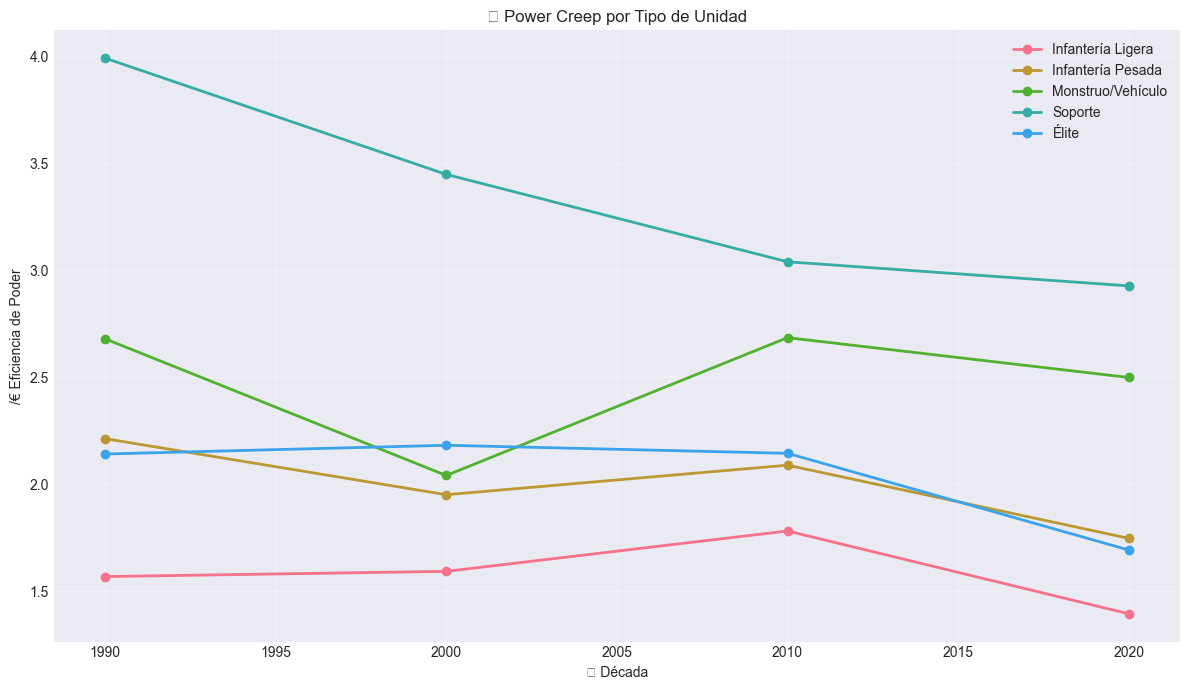

In [777]:
# 8.7 - Power creep por rol de unidad
role_trends = df_pc.groupby(['decade', 'unit_role'])['power_efficiency'].mean().unstack()

plt.figure(figsize=(12, 7))
for role in role_trends.columns:
    plt.plot(role_trends.index, role_trends[role], 
             marker='o', label=role, linewidth=2)

plt.xlabel('📆 Década')
plt.ylabel('/€ Eficiencia de Poder')
plt.title('🎭 Power Creep por Tipo de Unidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hipotesis_8_creep_by_role.png', dpi=300, bbox_inches='tight')


In [778]:
# 8.8 - Test estadístico: ¿Cambio significativo en eficiencia entre décadas?
from scipy.stats import ttest_ind

decade_2000 = df_pc[df_pc['decade'] == 2000]['power_efficiency'].dropna()
decade_2020 = df_pc[df_pc['decade'] == 2020]['power_efficiency'].dropna()

if len(decade_2000) > 10 and len(decade_2020) > 10:
    t_stat, p_value = ttest_ind(decade_2020, decade_2000, equal_var=False)
    effect_size = (decade_2020.mean() - decade_2000.mean()) / decade_2000.std()
    
    print("\n TEST ESTADÍSTICO: Power Creep 2000s vs 2020s")
    print(f"   Eficiencia media 2000s: {decade_2000.mean():.3f} /€")
    print(f"   Eficiencia media 2020s: {decade_2020.mean():.3f} /€")
    print(f"   Diferencia: {decade_2020.mean() - decade_2000.mean():+.3f} /€")
    print(f"   t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
    print(f"   Effect size (Cohen's d): {effect_size:.3f}")
    print(f"    {'Power creep detectado' if p_value < 0.05 and effect_size > 0.2 else '❌ Sin evidencia clara de power creep'}")



 TEST ESTADÍSTICO: Power Creep 2000s vs 2020s
   Eficiencia media 2000s: 1.973 /€
   Eficiencia media 2020s: 1.919 /€
   Diferencia: -0.055 /€
   t-statistic: -0.569, p-value: 0.5699
   Effect size (Cohen's d): -0.068
    ❌ Sin evidencia clara de power creep


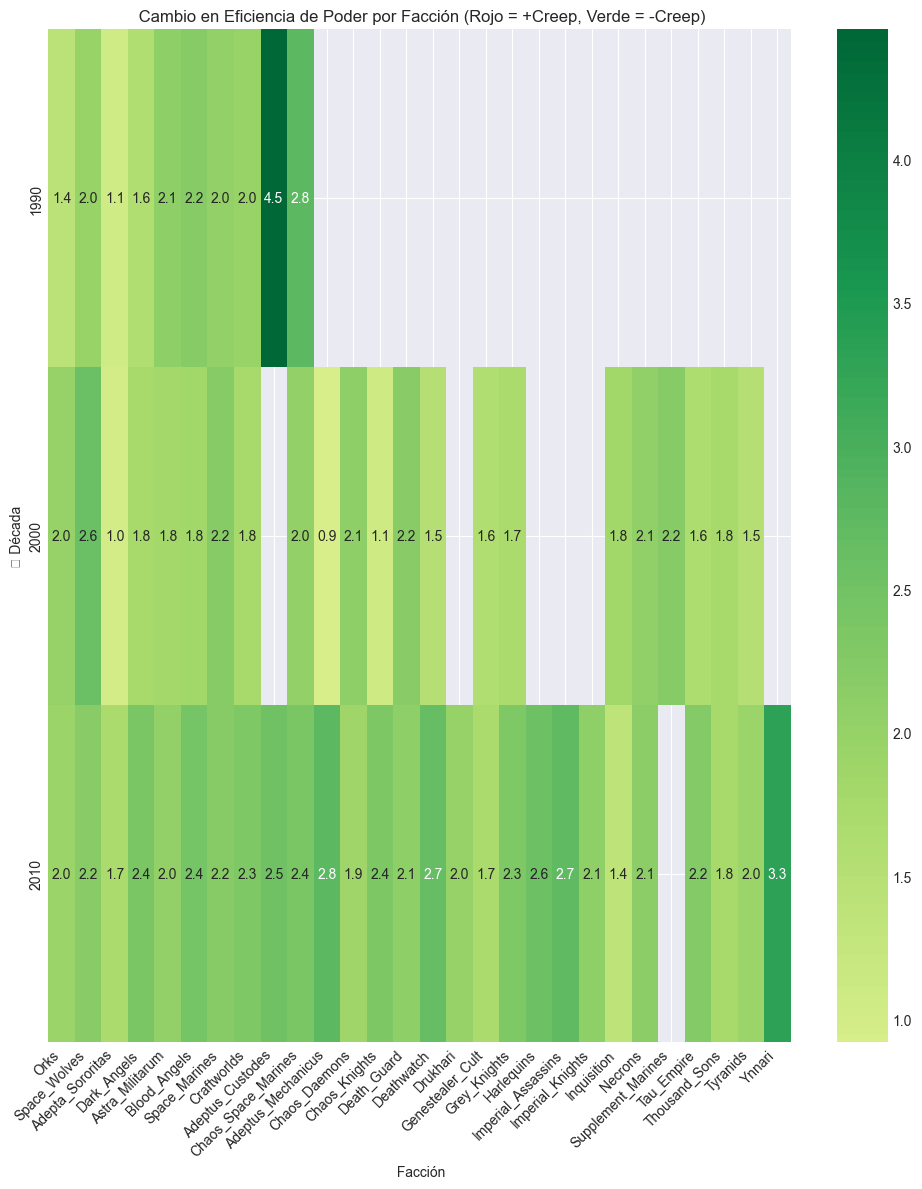

In [779]:
# 8.9 - Heatmap: Facciones con mayor cambio en eficiencia
faction_efficiency_change = df_pc.groupby(['faction_clean', 'decade'])['power_efficiency'].mean().unstack()

# Calcular cambio neto (última década disponible - primera)
faction_efficiency_change['net_change'] = (
    faction_efficiency_change.iloc[:, -1] - faction_efficiency_change.iloc[:, 0]
)

# Visualizar top/bottom
plt.figure(figsize=(10, 12))
sorted_factions = faction_efficiency_change.sort_values('net_change', ascending=False)
top_data = sorted_factions.drop(columns='net_change').iloc[:, :-1]  # Excluir columnas con muchos NaN

sns.heatmap(top_data.T, cmap='RdYlGn', center=0, annot=True, fmt='.1f')
plt.xlabel(' Facción')
plt.ylabel('📆 Década')
plt.title(' Cambio en Eficiencia de Poder por Facción (Rojo = +Creep, Verde = -Creep)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('hipotesis_8_faction_creep_heatmap.png', dpi=300, bbox_inches='tight')


In [780]:
# 8.10 - Función utilitaria: Detectar posibles casos de power creep extremo
def find_power_creep_outliers(threshold_std=2):
    """
    Identifica miniaturas con eficiencia de poder anormalmente alta
    para su año de lanzamiento
    """
    df_outliers = df_pc.copy()
    
    # Calcular z-score por año
    df_outliers['efficiency_zscore'] = df_outliers.groupby('year')['power_efficiency'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )
    
    # Filtrar outliers positivos (posible power creep)
    outliers = df_outliers[
        (df_outliers['efficiency_zscore'] > threshold_std) & 
        (df_outliers['year'] >= 2015)  # Solo miniaturas recientes
    ].sort_values('efficiency_zscore', ascending=False)
    
    return outliers[['mini', 'faction_clean', 'year', 'cost', 'price', 'power_efficiency', 'efficiency_zscore']]

# Ejecutar y mostrar resultados
creep_outliers = find_power_creep_outliers()

print("\n🚨 POSIBLES CASOS DE POWER CREEP (Eficiencia > 2σ sobre media anual):")
if not creep_outliers.empty:
    print(creep_outliers.head(15).to_string(index=False))
else:
    print("   No se detectaron outliers significativos con el umbral actual.")



🚨 POSIBLES CASOS DE POWER CREEP (Eficiencia > 2σ sobre media anual):
                 mini       faction_clean  year   cost  price  power_efficiency  efficiency_zscore
              SZAREKH             Necrons  2020 400.00  48.76              8.20               5.67
             Be'lakor       Chaos_Daemons  2021 375.00  55.20              6.79               5.33
            Mortarion         Death_Guard  2017 380.00  55.20              6.88               4.66
      Knight Rampager       Chaos_Knights  2019 365.00  78.20              4.67               3.92
    Roboute Guilliman       Space_Marines  2017 340.00  56.12              6.06               3.85
       Lion El'jonson         Dark_Angels  2023 315.00  67.62              4.66               3.85
           Stormsurge     Astra_Militarum  2015 400.00  55.20              7.25               3.46
              Praetor Chaos_Space_Marines  2018 275.00  56.12              4.90               3.32
              Praetor Chaos_Space_Marin

### 📏 HIPÓTESIS 9: Value Efficiency Analysis
#### ¿Pagamos por plástico o por marca?

In [781]:
# 9.1 - Preparación de datos: extraer valor numérico de base_mm2
df_ve = df_mini.copy()

def extract_base_size(base_str):
    """Extrae el valor numérico principal de campos como '40mm', '120 x 92mm', etc."""
    if pd.isna(base_str) or base_str == '':
        return np.nan
    if isinstance(base_str, (int, float)):
        return float(base_str)
    
    # Limpiar string
    base_str = str(base_str).strip().lower()
    
    # Caso especial: "Use model" o similares
    if 'use model' in base_str or 'flying' in base_str:
        return np.nan
    
    # Extraer números: priorizar el primero (dimensión principal)
    numbers = re.findall(r'(\d+(?:\.\d+)?)', base_str)
    if numbers:
        return float(numbers[0])
    return np.nan

In [782]:
df_ve['base_size_num'] = df_ve['base_mm2'].apply(extract_base_size)

# Calcular área aproximada (asumiendo base circular: π*r²)
df_ve['base_radius'] = df_ve['base_size_num'] / 2
df_ve['base_area_mm2'] = np.pi * (df_ve['base_radius'] ** 2)

# 9.2 - Calcular métrica clave: "Precio por mm²" (Value Efficiency)
df_ve_clean = df_ve.dropna(subset=['price', 'base_area_mm2']).copy()
df_ve_clean = df_ve_clean[df_ve_clean['base_area_mm2'] > 0].copy()  # Eliminar áreas inválidas

df_ve_clean['price_per_mm2'] = df_ve_clean['price'] / df_ve_clean['base_area_mm2']
df_ve_clean['cost_per_mm2'] = df_ve_clean['cost'] / df_ve_clean['base_area_mm2']  # Poder por área

print(f" Datos válidos para análisis: {len(df_ve_clean)} miniaturas")
print(f"\n Estadísticas de Precio por mm²:")
print(df_ve_clean['price_per_mm2'].describe())

 Datos válidos para análisis: 771 miniaturas

 Estadísticas de Precio por mm²:
count   771.00
mean      0.04
std       0.03
min       0.00
25%       0.02
50%       0.04
75%       0.06
max       0.12
Name: price_per_mm2, dtype: float64


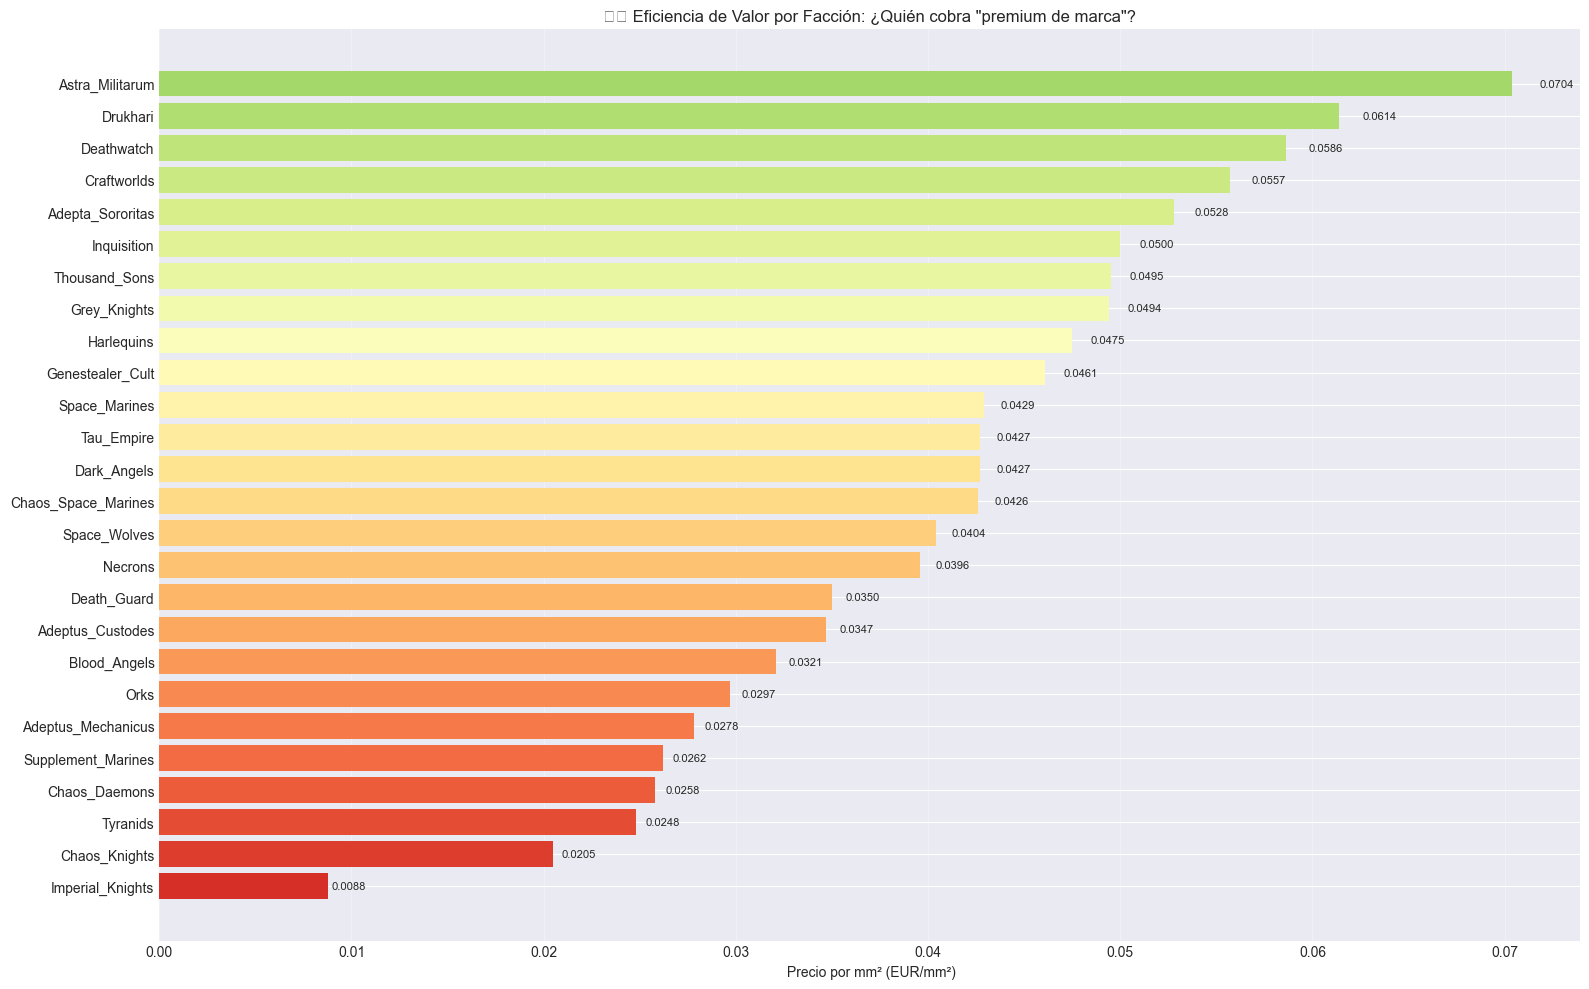

In [783]:
# 9.3 - Visualización 1: Distribución de price_per_mm2 por facción
plt.figure(figsize=(16, 10))
# Calcular estadísticas por facción
faction_efficiency = df_ve_clean.groupby('faction_clean').agg({
    'price_per_mm2': ['mean', 'median', 'std', 'count'],
    'price': 'mean',
    'base_area_mm2': 'mean'
}).round(4)
faction_efficiency.columns = ['ppm2_mean', 'ppm2_median', 'ppm2_std', 'count', 'price_mean', 'area_mean']
faction_efficiency = faction_efficiency[faction_efficiency['count'] >= 5]  # Mínimo de muestras

# Ordenar por precio por mm² medio
sorted_factions = faction_efficiency.sort_values('ppm2_mean', ascending=False)

# Gráfico de barras horizontal
bars = plt.barh(sorted_factions.index, sorted_factions['ppm2_mean'], 
                color=plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(sorted_factions))))

plt.xlabel(' Precio por mm² (EUR/mm²)')
plt.title('🏷️ Eficiencia de Valor por Facción: ¿Quién cobra "premium de marca"?')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Añadir labels con valores
for bar, faction in zip(bars, sorted_factions.index):
    width = bar.get_width()
    if width > 0:
        plt.text(width * 1.02, bar.get_y() + bar.get_height()/2, 
                f'{width:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('hipotesis_9_value_efficiency_by_faction.png', dpi=300, bbox_inches='tight')




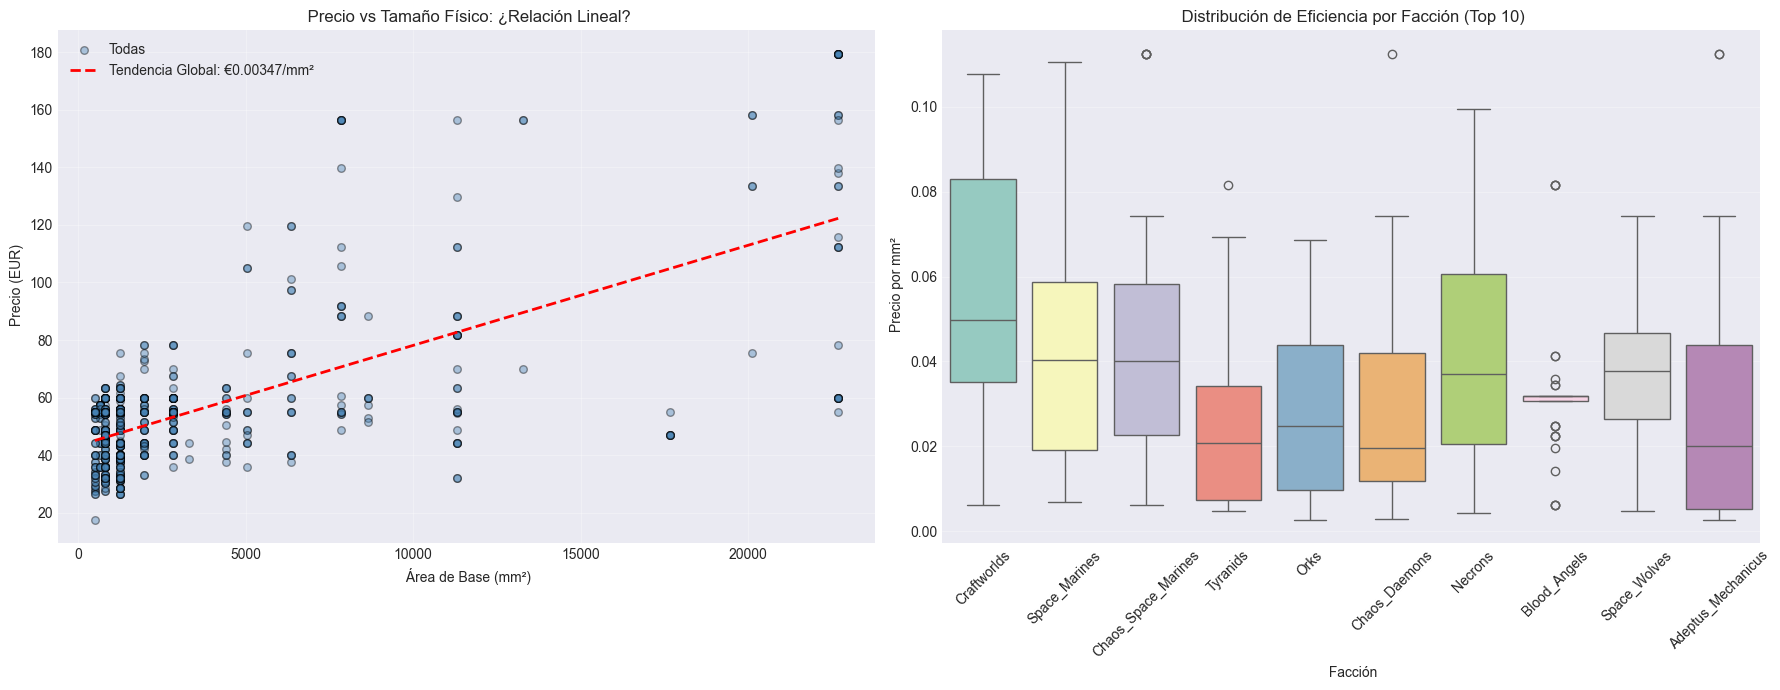

In [784]:
# 9.4 - Visualización 2: Scatter Price vs Área, coloreado por facción
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter global con tendencia
axes[0].scatter(df_ve_clean['base_area_mm2'], df_ve_clean['price'], 
                alpha=0.4, s=30, c='steelblue', edgecolors='black', label='Todas')

# Línea de regresión global
if len(df_ve_clean) > 2:
    z = np.polyfit(df_ve_clean['base_area_mm2'].dropna(), 
                   df_ve_clean['price'].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_ve_clean['base_area_mm2'].min(), 
                         df_ve_clean['base_area_mm2'].max(), 100)
    axes[0].plot(x_line, p(x_line), "r--", linewidth=2, 
                label=f'Tendencia Global: €{z[0]:.5f}/mm²')

axes[0].set_xlabel(' Área de Base (mm²)')
axes[0].set_ylabel(' Precio (EUR)')
axes[0].set_title(' Precio vs Tamaño Físico: ¿Relación Lineal?')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot por facción (top 10 por count)
top_factions = df_ve_clean['faction_clean'].value_counts().nlargest(10).index
subset = df_ve_clean[df_ve_clean['faction_clean'].isin(top_factions)]

sns.boxplot(data=subset, x='faction_clean', y='price_per_mm2', ax=axes[1], palette="Set3")
axes[1].set_xlabel(' Facción')
axes[1].set_ylabel(' Precio por mm²')
axes[1].set_title(' Distribución de Eficiencia por Facción (Top 10)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hipotesis_9_price_vs_size_analysis.png', dpi=300, bbox_inches='tight')



In [785]:
# 9.5 - Identificar "Premium de Marca": facciones con price_per_mm2 significativamente alto
global_mean = df_ve_clean['price_per_mm2'].mean()
global_std = df_ve_clean['price_per_mm2'].std()

# Calcular z-score por facción
faction_zscores = {}
for faction in faction_efficiency.index:
    faction_data = df_ve_clean[df_ve_clean['faction_clean'] == faction]['price_per_mm2']
    if len(faction_data) >= 5:
        z = (faction_data.mean() - global_mean) / global_std
        faction_zscores[faction] = {
            'z_score': z,
            'mean_ppm2': faction_data.mean(),
            'count': len(faction_data),
            'premium_pct': (faction_data.mean() / global_mean - 1) * 100
        }

premium_df = pd.DataFrame(faction_zscores).T
premium_df = premium_df.sort_values('z_score', ascending=False)

print("\n ANÁLISIS DE PREMIUM DE MARCA:")
print(f"   Media global: {global_mean:.5f} EUR/mm²")
print(f"   Desviación: {global_std:.5f} EUR/mm²\n")

print(" Facciones con MAYOR Premium (cobran más por mm²):")
print(premium_df[premium_df['z_score'] > 0].head(8)[['z_score', 'mean_ppm2', 'premium_pct', 'count']]
      .round(3).to_string())

print("\n💎 Facciones con MENOR Premium (mejor valor por mm²):")
print(premium_df[premium_df['z_score'] < 0].tail(8)[['z_score', 'mean_ppm2', 'premium_pct', 'count']]
      .round(3).to_string())



 ANÁLISIS DE PREMIUM DE MARCA:
   Media global: 0.04017 EUR/mm²
   Desviación: 0.02669 EUR/mm²

 Facciones con MAYOR Premium (cobran más por mm²):
                  z_score  mean_ppm2  premium_pct  count
Astra_Militarum      1.13       0.07        75.24  27.00
Drukhari             0.80       0.06        52.83  16.00
Deathwatch           0.69       0.06        45.84   7.00
Craftworlds          0.58       0.06        38.59  45.00
Adepta_Sororitas     0.47       0.05        31.57  28.00
Inquisition          0.37       0.05        24.61   8.00
Thousand_Sons        0.35       0.05        23.28  13.00
Grey_Knights         0.34       0.05        22.93  17.00

💎 Facciones con MENOR Premium (mejor valor por mm²):
                    z_score  mean_ppm2  premium_pct  count
Blood_Angels          -0.30       0.03       -20.18  48.00
Orks                  -0.39       0.03       -25.93  55.00
Adeptus_Mechanicus    -0.46       0.03       -30.79  36.00
Supplement_Marines    -0.52       0.03       -34.

In [786]:
# 9.6 - Test estadístico: ¿Diferencias significativas entre facciones?
from scipy.stats import f_oneway, ttest_ind

# Comparar top 3 vs bottom 3 en premium
top_premium = premium_df[premium_df['z_score'] > 0].head(3).index
bottom_premium = premium_df[premium_df['z_score'] < 0].tail(3).index

if len(top_premium) >= 2 and len(bottom_premium) >= 2:
    top_data = df_ve_clean[df_ve_clean['faction_clean'].isin(top_premium)]['price_per_mm2']
    bottom_data = df_ve_clean[df_ve_clean['faction_clean'].isin(bottom_premium)]['price_per_mm2']
    
    t_stat, p_value = ttest_ind(top_data, bottom_data, equal_var=False)
    effect_size = (top_data.mean() - bottom_data.mean()) / np.sqrt((top_data.std()**2 + bottom_data.std()**2)/2)
    
    print(f"\n TEST T: Premium Top vs Bottom")
    print(f"   Top Premium mean: {top_data.mean():.5f} EUR/mm²")
    print(f"   Bottom Premium mean: {bottom_data.mean():.5f} EUR/mm²")
    print(f"   Diferencia: {top_data.mean() - bottom_data.mean():+.5f} EUR/mm²")
    print(f"   t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
    print(f"   Effect size (Cohen's d): {effect_size:.3f}")
    print(f"    {'Diferencia ALTAMENTE significativa' if p_value < 0.01 else '❌ Sin diferencia clara'}")


 TEST T: Premium Top vs Bottom
   Top Premium mean: 0.06585 EUR/mm²
   Bottom Premium mean: 0.02111 EUR/mm²
   Diferencia: +0.04474 EUR/mm²
   t-statistic: 8.699, p-value: 0.0000
   Effect size (Cohen's d): 1.740
    Diferencia ALTAMENTE significativa



 ANÁLISIS POR TIER DE TAMAÑO:
                 price_per_mm2        price base_area_mm2       faction_clean
                          mean median  mean          mean            <lambda>
size_tier                                                                    
Tiny (<25mm)              0.09   0.10 44.92        490.87     Astra_Militarum
Small (25-40mm)           0.05   0.04 46.79       1120.41       Space_Marines
Medium (40-60mm)          0.02   0.02 54.68       3186.05       Space_Marines
Large (60-90mm)           0.01   0.01 76.74       6820.19       Space_Marines
Huge (90mm+)              0.01   0.01 97.57      17042.00  Adeptus_Mechanicus


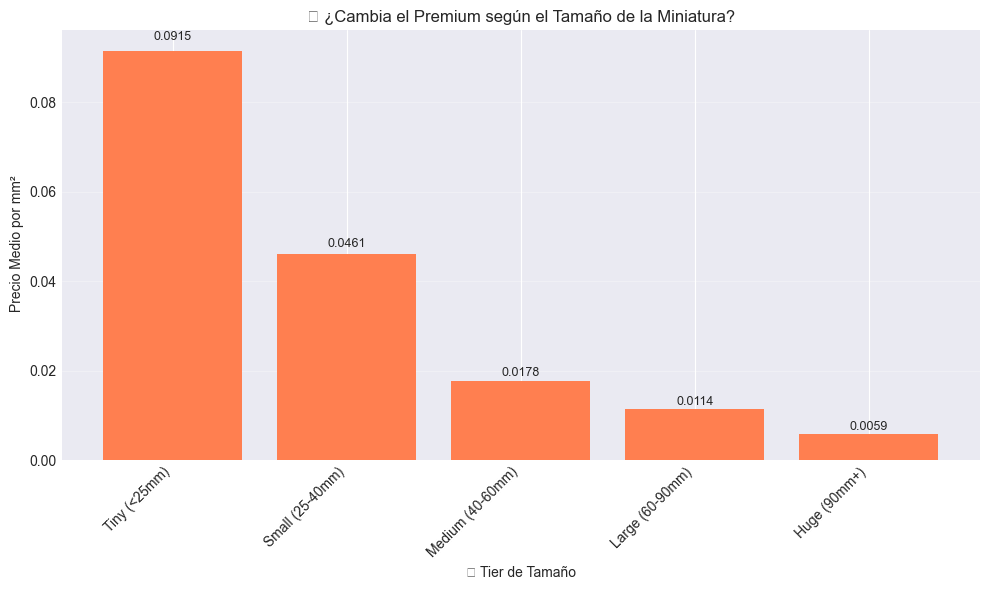

In [787]:
# 9.7 - Análisis por "tier de tamaño": ¿El premium cambia con el tamaño?
df_ve_clean['size_tier'] = pd.cut(
    df_ve_clean['base_area_mm2'],
    bins=[0, 500, 2000, 5000, 10000, 100000],
    labels=['Tiny (<25mm)', 'Small (25-40mm)', 'Medium (40-60mm)', 'Large (60-90mm)', 'Huge (90mm+)']
)

tier_analysis = df_ve_clean.groupby('size_tier').agg({
    'price_per_mm2': ['mean', 'median'],
    'price': 'mean',
    'base_area_mm2': 'mean',
    'faction_clean': lambda x: x.value_counts().index[0] if len(x) > 0 else 'N/A'
}).round(3)

print("\n ANÁLISIS POR TIER DE TAMAÑO:")
print(tier_analysis)

# Visualizar tier analysis
plt.figure(figsize=(10, 6))
tier_means = df_ve_clean.groupby('size_tier')['price_per_mm2'].mean()
bars = plt.bar(tier_means.index.astype(str), tier_means.values, color='coral')

plt.xlabel('📏 Tier de Tamaño')
plt.ylabel(' Precio Medio por mm²')
plt.title('🎭 ¿Cambia el Premium según el Tamaño de la Miniatura?')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Añadir valores en barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height * 1.02, 
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('hipotesis_9_premium_by_size_tier.png', dpi=300, bbox_inches='tight')



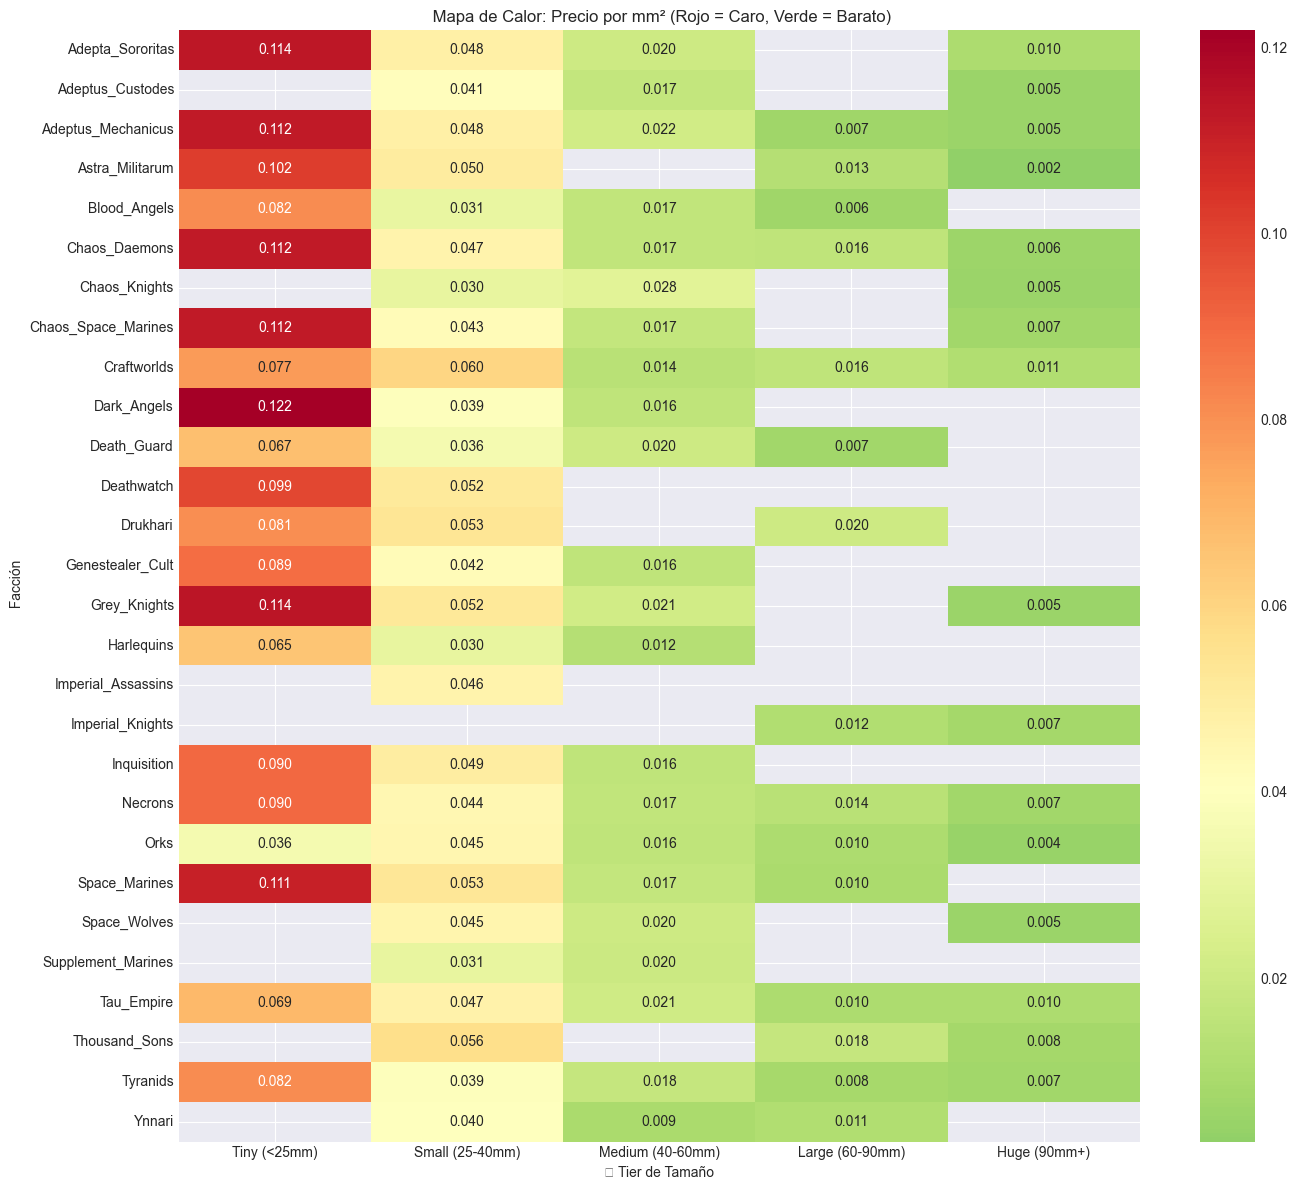

In [788]:
# 9.8 - Heatmap: Facción x Tier de Tamaño (precio por mm²)
heatmap_data = df_ve_clean.pivot_table(
    values='price_per_mm2', 
    index='faction_clean', 
    columns='size_tier', 
    aggfunc='mean'
)

plt.figure(figsize=(14, 12))
sns.heatmap(heatmap_data.dropna(how='all', axis=0).dropna(how='all', axis=1), 
            annot=True, fmt='.3f', cmap='RdYlGn_r', center=global_mean)
plt.xlabel('📏 Tier de Tamaño')
plt.ylabel(' Facción')
plt.title(' Mapa de Calor: Precio por mm² (Rojo = Caro, Verde = Barato)')
plt.tight_layout()
plt.savefig('hipotesis_9_heatmap_faction_size.png', dpi=300, bbox_inches='tight')


In [789]:
# 9.9 - Función utilitaria: ¿Vale la pena esta miniatura?
def evaluate_mini_value(mini_name, faction=None, target_price=None):
    """
    Evalúa si una miniatura específica tiene buen valor comparado con su facción.
    """
    # Buscar miniatura
    if faction:
        results = df_ve_clean[
            (df_ve_clean['mini'].str.contains(mini_name, case=False, na=False)) & 
            (df_ve_clean['faction_clean'] == faction)
        ]
    else:
        results = df_ve_clean[
            df_ve_clean['mini'].str.contains(mini_name, case=False, na=False)
        ]
    
    if results.empty:
        return f"❌ No se encontró '{mini_name}'{f' en {faction}' if faction else ''}"
    
    mini = results.iloc[0]
    faction_avg = df_ve_clean[df_ve_clean['faction_clean'] == mini['faction_clean']]['price_per_mm2'].mean()
    
    value_score = faction_avg / mini['price_per_mm2']  # >1 = buen valor, <1 = caro
    
    return f"""
    🔍 Evaluación: {mini['mini']} ({mini['faction_clean']})
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    📐 Área de base: {mini['base_area_mm2']:.0f} mm²
    💰 Precio actual: €{mini['price']:.2f}
    ⚡ Precio por mm²: {mini['price_per_mm2']:.5f} EUR/mm²
    📊 Promedio facción: {faction_avg:.5f} EUR/mm²

    🎯 Valor relativo: {value_score:.2f}x
    {'✅ BUEN VALOR' if value_score > 1.1 else '⚖️ PRECIO JUSTO' if value_score > 0.9 else '❌ PREMIUM ALTO'}

    💡 Consejo: {'¡Aprovéchalo!' if value_score > 1.2 else 'Precio estándar' if value_score > 0.85 else 'Espera oferta/re-edición'}
    """

In [790]:
# Ejemplos de uso
print("\n EJEMPLOS DE EVALUACIÓN DE VALOR:")
print(evaluate_mini_value("Wraithknight", "Craftworlds"))
print(evaluate_mini_value("Tactical Squad", "Space_Marines"))


 EJEMPLOS DE EVALUACIÓN DE VALOR:

    🔍 Evaluación: Wraithknight (Craftworlds)
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    📐 Área de base: 11310 mm²
    💰 Precio actual: €129.72
    ⚡ Precio por mm²: 0.01147 EUR/mm²
    📊 Promedio facción: 0.05567 EUR/mm²

    🎯 Valor relativo: 4.85x
    ✅ BUEN VALOR

    💡 Consejo: ¡Aprovéchalo!
    

    🔍 Evaluación: Tactical Squad (Space_Marines)
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    📐 Área de base: 804 mm²
    💰 Precio actual: €46.00
    ⚡ Precio por mm²: 0.05720 EUR/mm²
    📊 Promedio facción: 0.04289 EUR/mm²

    🎯 Valor relativo: 0.75x
    ❌ PREMIUM ALTO

    💡 Consejo: Espera oferta/re-edición
    


### HIPÓTESIS 13: ¿Las facciones con más "Primary" players tienen mejor soporte?
#### ¿Games Workshop prioriza facciones con base de jugadores leales?

In [791]:
# 13.1 - Preparación de métricas de "lealtad" y "soporte"
# Lealtad = Primary / Owned (proporción de jugadores que la usan como principal)
df_faction_clean = df_faction.copy()

# Limpiar datos numéricos
for col in ['Owned', 'Primary', 'Games', 'Win %', 'Real Win %']:
    df_faction_clean[col] = pd.to_numeric(
        df_faction_clean[col].astype(str).str.replace(',', '.'), 
        errors='coerce'
    )

# Calcular métrica de lealtad
df_faction_clean['loyalty_ratio'] = df_faction_clean['Primary'] / df_faction_clean['Owned']
df_faction_clean = df_faction_clean.dropna(subset=['loyalty_ratio', 'Owned', 'Primary'])

In [792]:
# 13.2 - Merge con métricas de soporte (cantidad de miniaturas, ediciones soportadas)
faction_support = df_mini.groupby('faction_clean').agg({
    'mini': 'count',  # Cantidad de miniaturas = proxy de soporte
    'edition': 'nunique',  # Ediciones soportadas
    'year': ['min', 'max'],  # Rango temporal de soporte
    'price': 'mean'  # Precio promedio
}).reset_index()
faction_support.columns = ['faction', 'mini_count', 'editions_supported', 'first_year', 'last_year', 'price_avg']

# Calcular años de soporte activo
faction_support['support_years'] = faction_support['last_year'] - faction_support['first_year'] + 1
faction_support['mini_per_year'] = faction_support['mini_count'] / faction_support['support_years']

# Merge con datos de lealtad
loyalty_support_merge = pd.merge(
    df_faction_clean[['faction_clean', 'Owned', 'Primary', 'loyalty_ratio', 'Games', 'Real Win %']],
    faction_support,
    left_on='faction_clean',
    right_on='faction',
    how='inner'
)

print(f" Datos válidos para análisis de lealtad: {len(loyalty_support_merge)} facciones")
print(f"\n Estadísticas de Lealtad:")
print(loyalty_support_merge['loyalty_ratio'].describe())

 Datos válidos para análisis de lealtad: 14 facciones

 Estadísticas de Lealtad:
count   14.00
mean     0.21
std      0.08
min      0.05
25%      0.18
50%      0.20
75%      0.28
max      0.31
Name: loyalty_ratio, dtype: float64


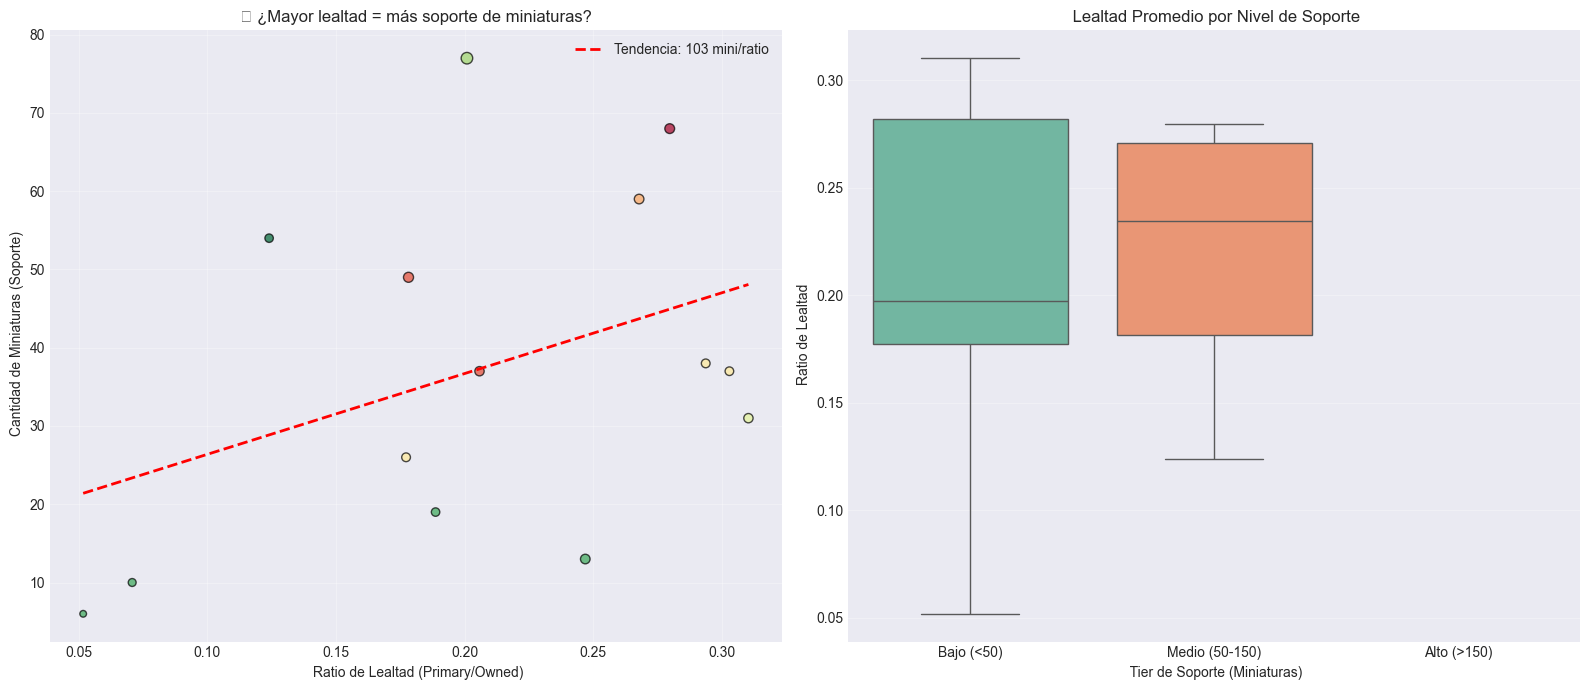

In [793]:
# 13.3 - Visualización 1: Lealtad vs Soporte (miniaturas)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter: Lealtad vs Cantidad de Miniaturas
axes[0].scatter(
    loyalty_support_merge['loyalty_ratio'],
    loyalty_support_merge['mini_count'],
    s=loyalty_support_merge['Owned'] / 10,
    c=loyalty_support_merge['Real Win %'],
    cmap='RdYlGn', alpha=0.7, edgecolors='black'
)
axes[0].set_xlabel(' Ratio de Lealtad (Primary/Owned)')
axes[0].set_ylabel(' Cantidad de Miniaturas (Soporte)')
axes[0].set_title('🔗 ¿Mayor lealtad = más soporte de miniaturas?')
axes[0].grid(alpha=0.3)

# Añadir línea de tendencia
if len(loyalty_support_merge) > 2:
    z = np.polyfit(loyalty_support_merge['loyalty_ratio'], loyalty_support_merge['mini_count'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(loyalty_support_merge['loyalty_ratio'].min(), 
                         loyalty_support_merge['loyalty_ratio'].max(), 100)
    axes[0].plot(x_line, p(x_line), "r--", linewidth=2, 
                label=f'Tendencia: {z[0]:.0f} mini/ratio')
    axes[0].legend()

# Boxplot: Lealtad por rango de soporte
loyalty_support_merge['support_tier'] = pd.cut(
    loyalty_support_merge['mini_count'],
    bins=[0, 50, 150, 500],
    labels=['Bajo (<50)', 'Medio (50-150)', 'Alto (>150)']
)
sns.boxplot(data=loyalty_support_merge, x='support_tier', y='loyalty_ratio', ax=axes[1], palette="Set2")
axes[1].set_xlabel(' Tier de Soporte (Miniaturas)')
axes[1].set_ylabel(' Ratio de Lealtad')
axes[1].set_title(' Lealtad Promedio por Nivel de Soporte')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hipotesis_13_loyalty_vs_support.png', dpi=300, bbox_inches='tight')



In [794]:
# 13.4 - Análisis de correlación
correlations_loyalty = {
    'loyalty_vs_minis': loyalty_support_merge['loyalty_ratio'].corr(loyalty_support_merge['mini_count']),
    'loyalty_vs_editions': loyalty_support_merge['loyalty_ratio'].corr(loyalty_support_merge['editions_supported']),
    'loyalty_vs_support_years': loyalty_support_merge['loyalty_ratio'].corr(loyalty_support_merge['support_years']),
    'loyalty_vs_games': loyalty_support_merge['loyalty_ratio'].corr(loyalty_support_merge['Games']),
    'loyalty_vs_winrate': loyalty_support_merge['loyalty_ratio'].corr(loyalty_support_merge['Real Win %'])
}

print("\n🔗 Correlaciones de Lealtad:")
for key, value in correlations_loyalty.items():
    print(f"   {key}: {value:.3f}")

# Test estadístico: ¿Diferencia significativa en lealtad entre alto/bajo soporte?
high_support = loyalty_support_merge[loyalty_support_merge['mini_count'] > 150]['loyalty_ratio']
low_support = loyalty_support_merge[loyalty_support_merge['mini_count'] < 50]['loyalty_ratio']

if len(high_support) > 3 and len(low_support) > 3:
    t_stat, p_value = stats.ttest_ind(high_support, low_support, equal_var=False)
    print(f"\n Test T: Lealtad Alto vs Bajo Soporte")
    print(f"   Alto soporte mean: {high_support.mean():.3f}")
    print(f"   Bajo soporte mean: {low_support.mean():.3f}")
    print(f"   t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
    print(f"   {' Diferencia significativa' if p_value < 0.05 else '❌ Sin diferencia significativa'}")



🔗 Correlaciones de Lealtad:
   loyalty_vs_minis: 0.392
   loyalty_vs_editions: 0.512
   loyalty_vs_support_years: 0.626
   loyalty_vs_games: 0.136
   loyalty_vs_winrate: -0.521


In [795]:
# 13.5 - Identificar patrones estratégicos: ¿Recompensa lealtad o atrae nuevos?
loyalty_support_merge['strategy_type'] = loyalty_support_merge.apply(
    lambda row: 'Recompensa Lealtad' if row['loyalty_ratio'] > 0.35 and row['mini_count'] > 100 else
                'Atrae Nuevos' if row['loyalty_ratio'] < 0.25 and row['mini_count'] > 100 else
                'Nicho Leal' if row['loyalty_ratio'] > 0.35 and row['mini_count'] < 50 else
                'En Desarrollo', axis=1
)

strategy_summary = loyalty_support_merge.groupby('strategy_type').agg({
    'faction_clean': lambda x: list(x),
    'loyalty_ratio': 'mean',
    'mini_count': 'mean',
    'Real Win %': 'mean',
    'Games': 'sum'
}).round(2)

print("\n Patrones Estratégicos Identificados:")
for strategy in strategy_summary.index:
    factions = strategy_summary.loc[strategy, 'faction_clean']
    print(f"\n {strategy}:")
    print(f"   Facciones: {', '.join(factions[:4])}{'...' if len(factions)>4 else ''}")
    print(f"   Lealtad Promedio: {strategy_summary.loc[strategy, 'loyalty_ratio']:.2%}")
    print(f"   Miniaturas Promedio: {strategy_summary.loc[strategy, 'mini_count']:.0f}")
    print(f"   Win Rate Promedio: {strategy_summary.loc[strategy, 'Real Win %']:.1f}%")



 Patrones Estratégicos Identificados:

 En Desarrollo:
   Facciones: Adepta_Sororitas, Adeptus_Custodes, Adeptus_Mechanicus, Craftworlds...
   Lealtad Promedio: 21.00%
   Miniaturas Promedio: 37
   Win Rate Promedio: 49.8%


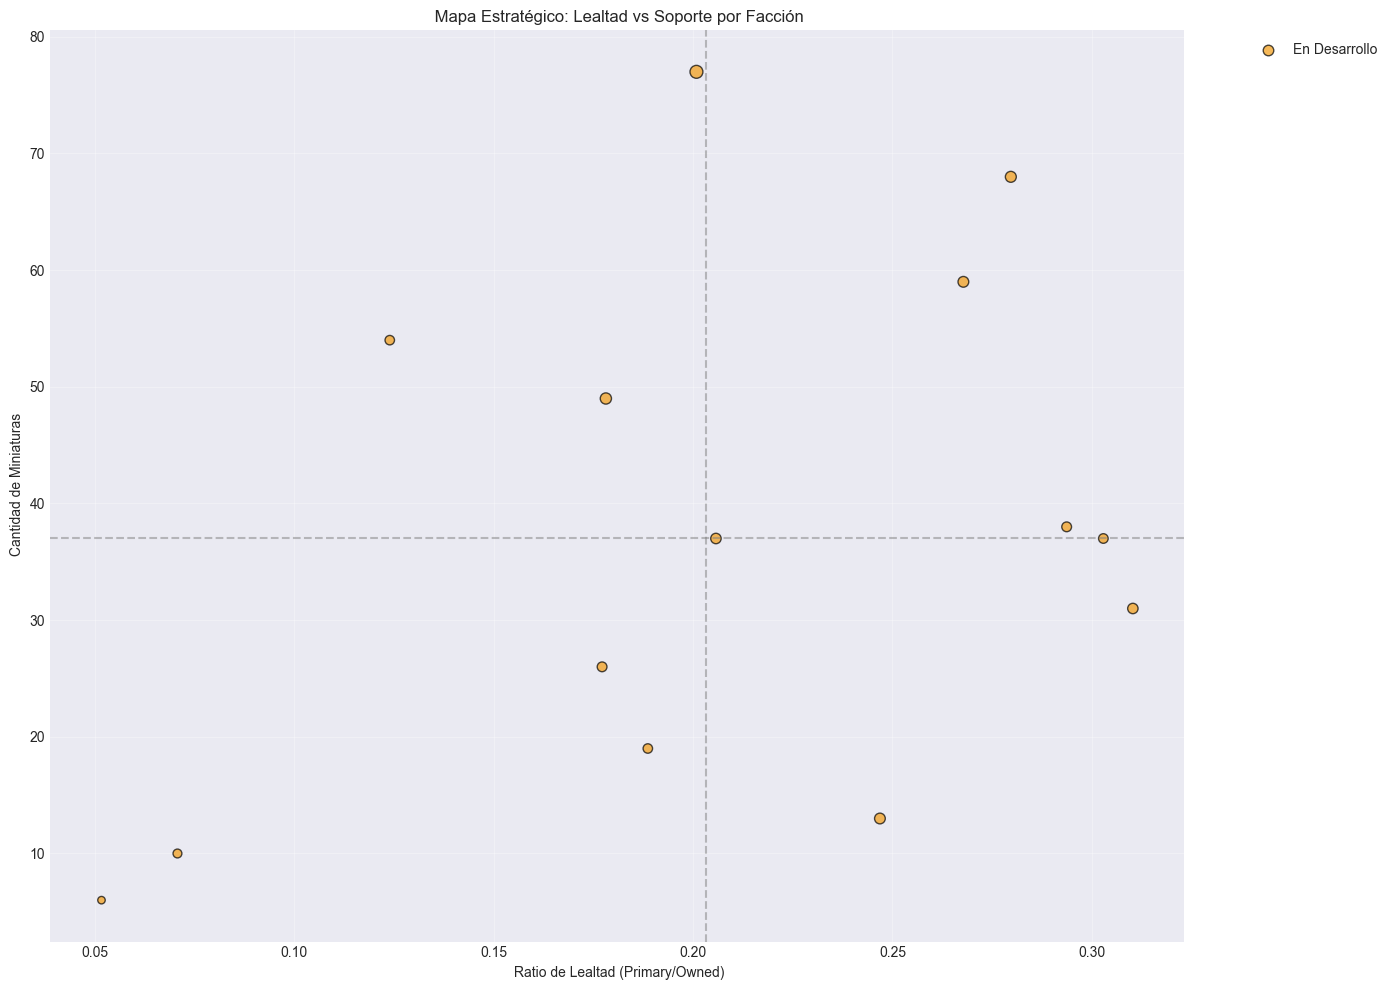

In [796]:
# 13.6 - Visualización 2: Mapa estratégico de facciones
plt.figure(figsize=(14, 10))

# Scatter: Lealtad vs Miniaturas, coloreado por estrategia
color_map = {
    'Recompensa Lealtad': '#2ecc71',
    'Atrae Nuevos': '#3498db', 
    'Nicho Leal': '#e74c3c',
    'En Desarrollo': '#f39c12'
}

for strategy in loyalty_support_merge['strategy_type'].unique():
    subset = loyalty_support_merge[loyalty_support_merge['strategy_type'] == strategy]
    plt.scatter(
        subset['loyalty_ratio'],
        subset['mini_count'],
        s=subset['Owned'] / 8,
        c=color_map.get(strategy, 'gray'),
        label=strategy, alpha=0.7, edgecolors='black'
    )

# Líneas de referencia para cuadrantes
plt.axvline(x=loyalty_support_merge['loyalty_ratio'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=loyalty_support_merge['mini_count'].median(), color='gray', linestyle='--', alpha=0.5)

plt.xlabel(' Ratio de Lealtad (Primary/Owned)')
plt.ylabel(' Cantidad de Miniaturas')
plt.title(' Mapa Estratégico: Lealtad vs Soporte por Facción')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()

# Anotar facciones destacadas
for _, row in loyalty_support_merge.iterrows():
    if row['loyalty_ratio'] > 0.4 or row['mini_count'] > 200:
        plt.annotate(row['faction_clean'][:12], (row['loyalty_ratio'], row['mini_count']), 
                    fontsize=7, xytext=(5, 5), textcoords='offset points')

plt.savefig('hipotesis_13_strategy_map.png', dpi=300, bbox_inches='tight')



In [797]:
# 13.7 - Función utilitaria: Analizar estrategia de facción
def analyze_faction_strategy(faction_name):
    """Analiza la estrategia de soporte para una facción específica"""
    faction_data = loyalty_support_merge[loyalty_support_merge['faction_clean'] == faction_name]
    if faction_data.empty:
        return f"❌ Facción '{faction_name}' no encontrada"
    
    row = faction_data.iloc[0]
    
    # Calcular percentiles para contexto
    loyalty_pct = (loyalty_support_merge['loyalty_ratio'] < row['loyalty_ratio']).mean() * 100
    support_pct = (loyalty_support_merge['mini_count'] < row['mini_count']).mean() * 100
    
    return f"""
🎯 Análisis Estratégico: {faction_name}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👥 Lealtad (Primary/Owned): {row['loyalty_ratio']:.2%} (Percentil: {loyalty_pct:.0f}%)
🎲 Soporte (Miniaturas): {row['mini_count']:.0f} (Percentil: {support_pct:.0f}%)
📚 Ediciones Soportadas: {row['editions_supported']:.0f}
🏆 Real Win Rate: {row['Real Win %']:.1f}%
🎮 Popularidad (Owned): {row['Owned']:.0f}

📋 Estrategia Identificada: {row['strategy_type']}

💡 Recomendación:
{
    '✅ Mantener inversión: facción leal y bien soportada' if row['strategy_type'] == 'Recompensa Lealtad' else
    '🎯 Oportunidad de crecimiento: alta lealtad, bajo soporte' if row['strategy_type'] == 'Nicho Leal' else
    '📈 Estrategia de expansión: bajo ratio de lealtad, alto soporte' if row['strategy_type'] == 'Atrae Nuevos' else
    '🔍 Monitorear: facción en fase de desarrollo'
}
"""


In [798]:
# Ejemplos de uso
print("\n EJEMPLOS DE ANÁLISIS ESTRATÉGICO:")
print(analyze_faction_strategy("Necrons"))
print(analyze_faction_strategy("Adepta_Sororitas"))


 EJEMPLOS DE ANÁLISIS ESTRATÉGICO:

🎯 Análisis Estratégico: Necrons
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👥 Lealtad (Primary/Owned): 20.09% (Percentil: 43%)
🎲 Soporte (Miniaturas): 77 (Percentil: 93%)
📚 Ediciones Soportadas: 8
🏆 Real Win Rate: 51.0%
🎮 Popularidad (Owned): 692

📋 Estrategia Identificada: En Desarrollo

💡 Recomendación:
🔍 Monitorear: facción en fase de desarrollo


🎯 Análisis Estratégico: Adepta_Sororitas
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👥 Lealtad (Primary/Owned): 31.03% (Percentil: 93%)
🎲 Soporte (Miniaturas): 31 (Percentil: 36%)
📚 Ediciones Soportadas: 6
🏆 Real Win Rate: 50.0%
🎮 Popularidad (Owned): 448

📋 Estrategia Identificada: En Desarrollo

💡 Recomendación:
🔍 Monitorear: facción en fase de desarrollo

